# Project: Aanwezigheden tijdens lessen
## Machine Learning — Voorspelling aanwezigheidsgraad

**Student:** Rodrigo Verschraegen
**Opleiding:** AI & Data Engineering  
**Academiejaar:** 2025-2026 - EK:2

**Doel:** Het bouwen van een regressie model dat de aanwezigingsgraad voorspelt voor een bepaalde 'les'. Dit aan de hand van het tijdstip, subgroep, vak, lokaalverderdeling, weersomstandigheden, academische kalender, stakingsdagen en WIFI data.

---


# Deel 0 — Imports
---


In [1]:
import pandas as pd
from pandas import Timestamp
import requests
import matplotlib.pyplot as plt

---

# Fase 1  — Importeren & mergen data
---
**Doel:** Importeren van CSV bestanden en samenvoegen tot één gebruikbaar geheel (dataframe) met als ultieme doel de ('aanwezigheidsgraad') te berekenen.


* De basisgegevens zijn afkomstig uit het WifiDWH. De relevante feiten- en dimensietabellen werden in SQL samengevoegd in een view en vervolgens
geëxporteerd naar een CSV-bestand.
* Daarnaast wordt externe historische weerdata voor Gent opgehaald via de Open-Meteo Historical Weather API. De weerdata wordt later gekoppeld aan
iedere les op basis van datum en startuur.

**1.1                Inezen Fact table, export uit SQL**

SQL qeury die gebruikt is kan je terugvinden in de projectfolder in het bestand (project_aanwezigheden_adendum)

In [2]:
df = pd.read_csv("dataset_aanwezigheden.csv", sep=";", encoding="utf-8-sig")


In [3]:
df.head() #check and inspect CSV

,LectureID,DateKey,FromTimeKey,UntilTimeKey,ClassKey,SubgroupKey,RoomKey,ActivityKey,UserCount,TotalStudents,...,SubgroupCode,ProgramName,Building,RoomFloor,RoomCode,RoomName,RoomCategory,Capacity,Area,Stakingsdag
0,482702,20251215,81500,91500,4136,5807208,1116,2,3.0,26,...,PBA-TIN-TI/2A2,PBA-TIN-TI,2,1,01.02.110.017,GSCHB.1.017,auditorium,110,128.05,0
1,482702,20251215,81500,91500,4136,5939143,1116,2,0.0,13,...,PBA-TIN-TI/2D,PBA-TIN-TI,2,1,01.02.110.017,GSCHB.1.017,auditorium,110,128.05,0
2,482702,20251215,81500,91500,4136,5976638,1116,2,0.0,6,...,PBA-TIN-TI/VT/NET/S1,PBA-TIN-TI,2,1,01.02.110.017,GSCHB.1.017,auditorium,110,128.05,0
3,482702,20251215,81500,91500,4136,5787959,1116,2,1.0,7,...,PBA-TIN-TI/2B,PBA-TIN-TI,2,1,01.02.110.017,GSCHB.1.017,auditorium,110,128.05,0
4,482702,20251215,81500,91500,4136,5788163,1116,2,14.0,55,...,PBA-TIN-TI/2C1,PBA-TIN-TI,2,1,01.02.110.017,GSCHB.1.017,auditorium,110,128.05,0


In [4]:
df.tail() #check

,LectureID,DateKey,FromTimeKey,UntilTimeKey,ClassKey,SubgroupKey,RoomKey,ActivityKey,UserCount,TotalStudents,...,SubgroupCode,ProgramName,Building,RoomFloor,RoomCode,RoomName,RoomCategory,Capacity,Area,Stakingsdag
18494,465361,20260521,180000,220000,10119,6062890,1580,2,NaN,8,...,PBA-VEB/AVOND/2B,PBA-VEB,2,2,01.02.120.005,GSCHB.2.005,leslokaal,76,94.26,0
18495,465509,20260326,180000,220000,10122,6063000,1604,2,NaN,5,...,PBA-VEB/AVOND/3B,PBA-VEB,2,1,01.02.110.012,GSCHB.1.012,leslokaal,45,73.75,0
18496,465510,20260430,180000,220000,10122,6063000,1604,2,NaN,5,...,PBA-VEB/AVOND/3B,PBA-VEB,2,1,01.02.110.012,GSCHB.1.012,leslokaal,45,73.75,0
18497,476213,20251119,180000,220000,6430,5722892,1580,2,5.0,6,...,BNB-TFISC/1,BNB-TFISC,2,2,01.02.120.005,GSCHB.2.005,leslokaal,76,94.26,0
18498,479202,20260115,180000,220000,10110,6062417,1616,19,NaN,130,...,PBA-VEB/AVOND/1A,PBA-VEB,2,2,01.02.120.008,GSCHB.2.008,leslokaal,41,55.93,0


In [5]:
df.info() #check

<class 'pandas.DataFrame'>
RangeIndex: 18499 entries, 0 to 18498
Data columns (total 57 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   LectureID          18499 non-null  int64  
 1   DateKey            18499 non-null  int64  
 2   FromTimeKey        18499 non-null  int64  
 3   UntilTimeKey       18499 non-null  int64  
 4   ClassKey           18499 non-null  int64  
 5   SubgroupKey        18499 non-null  int64  
 6   RoomKey            18499 non-null  int64  
 7   ActivityKey        18499 non-null  int64  
 8   UserCount          6977 non-null   float64
 9   TotalStudents      18499 non-null  int64  
 10  FullDate           18499 non-null  str    
 11  NameDayDutch       18499 non-null  str    
 12  NameMonthDutch     18499 non-null  str    
 13  Weekday            18499 non-null  int64  
 14  Month              18499 non-null  int64  
 15  Year               18499 non-null  int64  
 16  DayOfYear          18499 non-null

In [6]:
# Datumkolom omzetten naar een echt datumtype
df["FullDate"] = pd.to_datetime(df["FullDate"], errors="coerce")

# Minimumdatum uit de CSV bepalen, is nodig om later de API te laten mergen met de CSV
start_lesdatum_semester_1 = pd.Timestamp("2025-09-22")
laatste_lesdatum_semester_1 = pd.Timestamp("2025-12-19")

print("De start van het eerste semester / academiejaar is op:", start_lesdatum_semester_1)
print("De laatste les van het eerste semester is op:", laatste_lesdatum_semester_1, "Laatste vrijdag voor het kerstreces.")

De start van het eerste semester / academiejaar is op: 2025-09-22 00:00:00
De laatste les van het eerste semester is op: 2025-12-19 00:00:00 Laatste vrijdag voor het kerstreces.


**1.2                Open-Meteo weerdata ophalen via API**

In [7]:
# Inladen van historische weerdata via Open-Meteo API

import requests

# Timestamps omzetten naar het datumformaat dat de API verwacht
start_date_api = start_lesdatum_semester_1.strftime("%Y-%m-%d")
end_date_api = laatste_lesdatum_semester_1.strftime("%Y-%m-%d")

print("Startdatum API:", start_date_api)
print("Einddatum API:", end_date_api)

# Coördinaten van Gent
latitude = 51.05
longitude = 3.72

# API-endpoint
url = "https://archive-api.open-meteo.com/v1/archive"

# Parameters van de API-aanvraag
params = {
    "latitude": latitude,
    "longitude": longitude,
    "start_date": start_date_api,
    "end_date": end_date_api,
    "daily": [
        "temperature_2m_mean",
        "temperature_2m_max",
        "temperature_2m_min",
        "precipitation_sum",
        "rain_sum",
        "wind_speed_10m_max",
        "weather_code",
        "sunshine_duration",
        "daylight_duration",
        "precipitation_hours"
],
    
    "timezone": "Europe/Brussels"
}

# API-aanvraag uitvoeren
response = requests.get(
    url,
    params=params,
    timeout=60
)

print("Statuscode:", response.status_code)

# Foutmelding geven als de aanvraag mislukt
response.raise_for_status()

# JSON-data ophalen
weather_json = response.json()

# Dagelijkse weerdata omzetten naar DataFrame
weather_df = pd.DataFrame(weather_json["daily"])

# Datumkolom omzetten naar datetime
weather_df["time"] = pd.to_datetime(
    weather_df["time"],
    errors="coerce"
)

# Datumkolom dezelfde naam geven als in de CSV
weather_df = weather_df.rename(
    columns={"time": "FullDate"}
)

print("Aantal rijen en kolommen:", weather_df.shape)

weather_df.head()

weather_df = weather_df.rename(columns={
    "time": "FullDate",
    "temperature_2m_mean": "GemiddeldeTemperatuur",
    "temperature_2m_max": "MaximumTemperatuur",
    "temperature_2m_min": "MinimumTemperatuur",
    "precipitation_sum": "TotaleNeerslag",
    "rain_sum": "TotaleRegen",
    "wind_speed_10m_max": "MaximaleWindsnelheid",
    "weather_code": "WeerCode",
    "sunshine_duration": "ZonneschijnSeconden",
    "daylight_duration": "DaglichtSeconden",
    "precipitation_hours": "NeerslagUren"
})

Startdatum API: 2025-09-22
Einddatum API: 2025-12-19
Statuscode: 200
Aantal rijen en kolommen: (89, 11)


In [8]:
weather_df.head() #check of dataset werkt

,FullDate,GemiddeldeTemperatuur,MaximumTemperatuur,MinimumTemperatuur,TotaleNeerslag,TotaleRegen,MaximaleWindsnelheid,WeerCode,ZonneschijnSeconden,DaglichtSeconden,NeerslagUren
0,2025-09-22,12.4,15.8,9.6,0.1,0.1,20.0,51,40700.32,43912.03,1.0
1,2025-09-23,12.5,16.6,9.3,0.0,0.0,18.1,3,24838.01,43683.33,0.0
2,2025-09-24,12.3,15.9,8.8,0.0,0.0,22.1,3,31104.07,43455.44,0.0
3,2025-09-25,11.1,13.7,8.9,0.2,0.2,17.5,51,20324.16,43226.80,2.0
4,2025-09-26,11.3,15.2,7.4,0.1,0.1,11.1,51,17812.78,42997.14,1.0


In [9]:
weather_df.tail() #check

,FullDate,GemiddeldeTemperatuur,MaximumTemperatuur,MinimumTemperatuur,TotaleNeerslag,TotaleRegen,MaximaleWindsnelheid,WeerCode,ZonneschijnSeconden,DaglichtSeconden,NeerslagUren
84,2025-12-15,7.4,9.5,5.3,0.0,0.0,19.0,3,18505.22,28560.34,0.0
85,2025-12-16,9.6,12.1,7.4,0.2,0.2,14.5,51,10521.98,28525.79,2.0
86,2025-12-17,8.1,9.9,6.6,0.0,0.0,17.5,3,11255.55,28497.35,0.0
87,2025-12-18,10.0,13.4,6.5,0.6,0.6,28.4,51,7200.00,28475.02,3.0
88,2025-12-19,10.0,12.9,6.6,7.6,7.6,25.3,61,9134.33,28458.83,12.0


**1.3 Beide datasets mergen**


In [10]:
#CSV-data en weerdata samenvoegen

df["FullDate"] = pd.to_datetime(df["FullDate"], errors="coerce")
weather_df["FullDate"] = pd.to_datetime(
    weather_df["FullDate"],
    errors="coerce"
)

df_merged = df.merge(
    weather_df,
    on="FullDate",
    how="left",
    validate="many_to_one"
)

print("Originele dataset:", df.shape)
print("Weerdataset:", weather_df.shape)
print("Samengevoegde dataset:", df_merged.shape)
print("Aantal rijen behouden:", len(df) == len(df_merged))



Originele dataset: (18499, 57)
Weerdataset: (89, 11)
Samengevoegde dataset: (18499, 67)
Aantal rijen behouden: True


In [11]:
df_merged.head() #check

,LectureID,DateKey,FromTimeKey,UntilTimeKey,ClassKey,SubgroupKey,RoomKey,ActivityKey,UserCount,TotalStudents,...,GemiddeldeTemperatuur,MaximumTemperatuur,MinimumTemperatuur,TotaleNeerslag,TotaleRegen,MaximaleWindsnelheid,WeerCode,ZonneschijnSeconden,DaglichtSeconden,NeerslagUren
0,482702,20251215,81500,91500,4136,5807208,1116,2,3.0,26,...,7.4,9.5,5.3,0.0,0.0,19.0,3.0,18505.22,28560.34,0.0
1,482702,20251215,81500,91500,4136,5939143,1116,2,0.0,13,...,7.4,9.5,5.3,0.0,0.0,19.0,3.0,18505.22,28560.34,0.0
2,482702,20251215,81500,91500,4136,5976638,1116,2,0.0,6,...,7.4,9.5,5.3,0.0,0.0,19.0,3.0,18505.22,28560.34,0.0
3,482702,20251215,81500,91500,4136,5787959,1116,2,1.0,7,...,7.4,9.5,5.3,0.0,0.0,19.0,3.0,18505.22,28560.34,0.0
4,482702,20251215,81500,91500,4136,5788163,1116,2,14.0,55,...,7.4,9.5,5.3,0.0,0.0,19.0,3.0,18505.22,28560.34,0.0


In [12]:
df_merged.tail() #check of data set goed is gemerged want 2025 zou wel moeten gevuld zijn

,LectureID,DateKey,FromTimeKey,UntilTimeKey,ClassKey,SubgroupKey,RoomKey,ActivityKey,UserCount,TotalStudents,...,GemiddeldeTemperatuur,MaximumTemperatuur,MinimumTemperatuur,TotaleNeerslag,TotaleRegen,MaximaleWindsnelheid,WeerCode,ZonneschijnSeconden,DaglichtSeconden,NeerslagUren
18494,465361,20260521,180000,220000,10119,6062890,1580,2,NaN,8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18495,465509,20260326,180000,220000,10122,6063000,1604,2,NaN,5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18496,465510,20260430,180000,220000,10122,6063000,1604,2,NaN,5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18497,476213,20251119,180000,220000,6430,5722892,1580,2,5.0,6,...,5.0,7.3,3.5,5.6,5.6,20.4,61.0,5865.81,31411.83,10.0
18498,479202,20260115,180000,220000,10110,6062417,1616,19,NaN,130,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---
# Fase 2  — Doel
---
**Doel:** Aanwezigheidsgraad is het verwacht aantal studenten dat effectief aanwezig was, dit gemeten aan de had van Wifi-Verbindingen. Zo kunnen we de lessen eerlijk met elkaar vergelijken en krijgt het model een gestandaardiseerde target.



In [13]:
df_merged['aanwezigheidsgraad'] = df_merged['UserCount'] / df_merged['TotalStudents']
df_merged['aanwezigheidsgraad'].describe().round(3)

count    6977.000
mean        0.328
std         0.287
min         0.000
25%         0.026
50%         0.306
75%         0.533
max         1.000
Name: aanwezigheidsgraad, dtype: float64

# Fase 3  — Data verkennen en controleren


**3.1 Basis Controles**


In [14]:
# Afmetingen
print(df_merged.shape)

# Datatypes en ontbrekende waarden
df_merged.info()


(18499, 68)
<class 'pandas.DataFrame'>
RangeIndex: 18499 entries, 0 to 18498
Data columns (total 68 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   LectureID              18499 non-null  int64         
 1   DateKey                18499 non-null  int64         
 2   FromTimeKey            18499 non-null  int64         
 3   UntilTimeKey           18499 non-null  int64         
 4   ClassKey               18499 non-null  int64         
 5   SubgroupKey            18499 non-null  int64         
 6   RoomKey                18499 non-null  int64         
 7   ActivityKey            18499 non-null  int64         
 8   UserCount              6977 non-null   float64       
 9   TotalStudents          18499 non-null  int64         
 10  FullDate               18499 non-null  datetime64[us]
 11  NameDayDutch           18499 non-null  str           
 12  NameMonthDutch         18499 non-null  str           
 13  

Observaties: 
- 18499 geregistreerde lessen, PER subgroep, 1 les bestaat uit meerdere records
- UserCount heeft slechts 6977 ingevulde waarden, hier moet dus extra naar gekeken worden
- Season, ClassCode, RoomCode, RoomCategory, ProgramName, SubgroupCode, CanoicalActivity, ActivityGroup zijn strings, FullDate date time US (om CSVs te mergen)


**3.2 Controleren op ontbrekende waarden**

In [15]:
missing_values = df_merged.isnull().sum().sort_values(ascending=False)

display(missing_values.to_frame("Aantal ontbrekende waarden"))

,Aantal ontbrekende waarden
aanwezigheidsgraad,11522
UserCount,11522
ZonneschijnSeconden,11473
NeerslagUren,11473
TotaleRegen,11473
...,...
Stakingsdag,0
RoomName,0
RoomCategory,0
Capacity,0


Observatie:
- UserCount heeft 11522 ontbrekende waarden
- de toegevoegde weather gegevens 11472, is logisch want ze zijn slechts ingeladen in de data set tot 2025-12-19

**3.2 Checken op duplicaten**

In [16]:
print("Aantal duplicaten:", df_merged.duplicated().sum())

Aantal duplicaten: 0


**3.3 Beschrijvende statistieken**

In [17]:
df_merged.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
LectureID,18499.0,NaN,NaN,NaN,431705.607438,322922.0,404821.5,438529.0,454170.5,485352.0,32144.944307
DateKey,18499.0,NaN,NaN,NaN,20256821.192389,20250925.0,20251120.0,20260219.0,20260326.0,20260616.0,4491.049959
FromTimeKey,18499.0,NaN,NaN,NaN,117142.818531,80000.0,91500.0,103000.0,133000.0,203000.0,28207.569434
UntilTimeKey,18499.0,NaN,NaN,NaN,140297.799881,91500.0,123000.0,123000.0,164500.0,220000.0,29537.062652
ClassKey,18499.0,NaN,NaN,NaN,5396.714417,17.0,4131.0,4789.0,5815.0,11976.0,1895.496887
...,...,...,...,...,...,...,...,...,...,...,...
WeerCode,7026.0,NaN,NaN,NaN,40.662681,3.0,3.0,51.0,53.0,75.0,23.848193
ZonneschijnSeconden,7026.0,NaN,NaN,NaN,16005.472464,0.0,6285.92,15943.26,25384.5,39600.0,11394.018235
DaglichtSeconden,7026.0,NaN,NaN,NaN,34547.335894,28458.83,30205.57,34260.61,38627.65,43226.8,4631.981964
NeerslagUren,7026.0,NaN,NaN,NaN,3.963849,0.0,0.0,3.0,5.0,18.0,4.433307


**3.4 Datum bereik volledige dataset controleren**

In [18]:
print("Eerste datum:", df_merged["FullDate"].min())
print("Laatste datum:", df_merged["FullDate"].max())

Eerste datum: 2025-09-25 00:00:00
Laatste datum: 2026-06-16 00:00:00


**3.4.1 Null & Not Null values doorheen de tijd (Semester 1 & 2**)

Op user count

In [19]:
# Splits de data in rijen met en zonder UserCount
null_df = df_merged[df_merged["UserCount"].isnull()]
not_null_df = df_merged[df_merged["UserCount"].notnull()]

# Aantal rijen per dag
nulls_per_dag = null_df.groupby("FullDate").size()
notnull_per_dag = not_null_df.groupby("FullDate").size()


**3.4.2 Suppot plot / Grafiek**

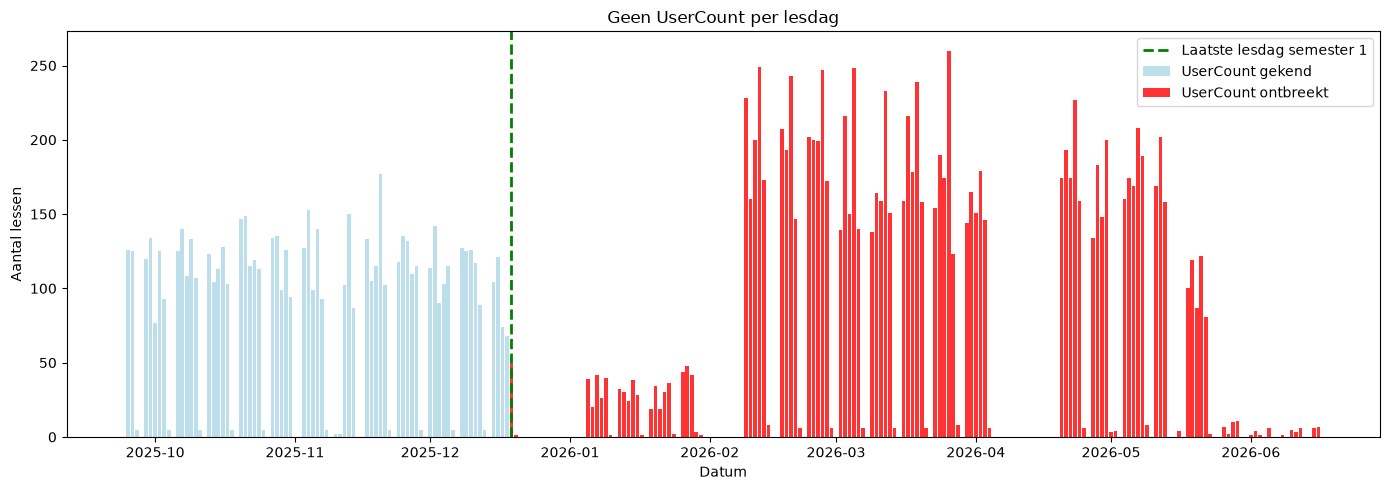

In [20]:
# Grafiek
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(
    notnull_per_dag.index,
    notnull_per_dag.values,
    color="lightblue",
    alpha=0.8,
    label="UserCount gekend"
)

ax.bar(
    nulls_per_dag.index,
    nulls_per_dag.values,
    color="red",
    alpha=0.8,
    label="UserCount ontbreekt"
)

# Laatste lesdag semester 1
ax.axvline(
    laatste_lesdatum_semester_1,
    color="green",
    linestyle="--",
    linewidth=2,
    label="Laatste lesdag semester 1"
)

ax.set_title("Geen UserCount per lesdag")
ax.set_xlabel("Datum")
ax.set_ylabel("Aantal lessen")
ax.legend()

plt.tight_layout()
plt.show()

**3.5 Observaties**

In [21]:
# opslaan van originele data
df_merged_raw = df_merged.copy()

print(f"Totaal aantal rijen vóór data cleaning: {len(df_merged_raw):,}")
print(f"Rijen met ontbrekende UserCount: {df_merged_raw['UserCount'].isnull().sum():,}")

# Verwijder alle rijen zonder UserCount (null)
df_merged = df_merged[df_merged["UserCount"].notna()]

print(f"\nTotaal aantal rijen na cleaning: {len(df_merged):,}")
print(f"Totaal aantal verwijderde rijen: {len(df_merged_raw) - len(df_merged):,}")

Totaal aantal rijen vóór data cleaning: 18,499
Rijen met ontbrekende UserCount: 11,522

Totaal aantal rijen na cleaning: 6,977
Totaal aantal verwijderde rijen: 11,522


**3.5.1 Observaties**
* Toekomstdata toont enkel null waarde, indicatie dat we deze mogen droppen. Kunnen niet in de toekomst kijken. Anders is er (target) data leakage als we die meenemen.
* Data beschikbaar vanaf 25-09-2025 t.e.m 19-12-2025


**3.6 Diepere verkenning**

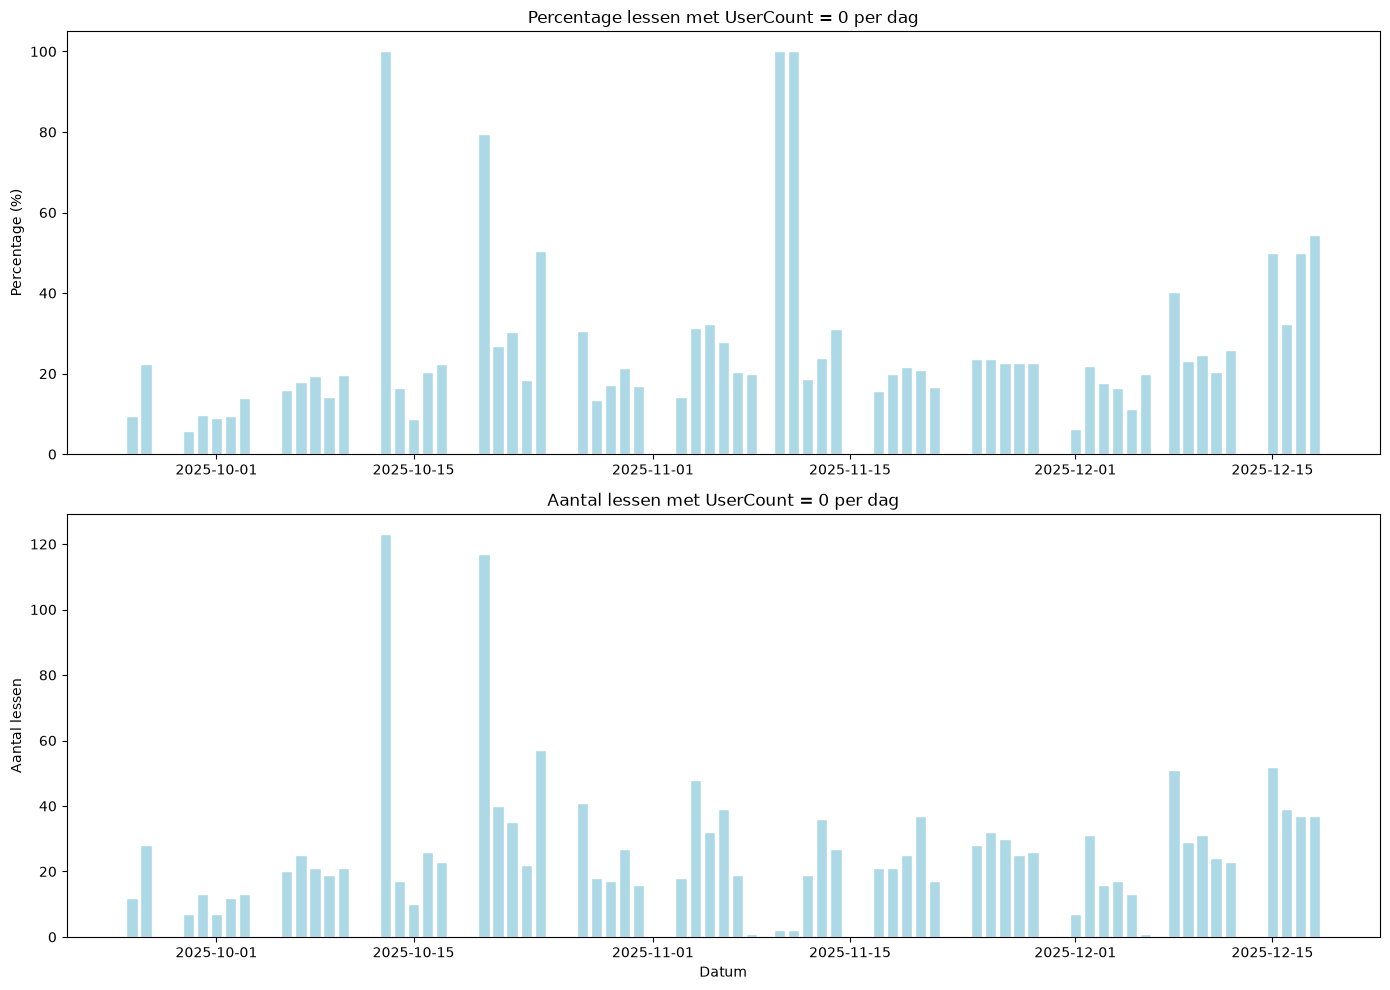

In [22]:
# Per dag: hoeveel % van de lessen heeft een UserCount van 0?

nul_per_dag = df_merged.groupby("FullDate").apply(
    lambda x: (x["UserCount"] == 0).sum() / len(x) * 100,
    include_groups=False
).reset_index(name="PercentageNul")

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Grafiek 1: percentage lessen met UserCount = 0
ax = axes[0]
ax.bar(
    nul_per_dag["FullDate"],
    nul_per_dag["PercentageNul"],
    color="lightblue",
    edgecolor="white"
)

ax.set_title("Percentage lessen met UserCount = 0 per dag")
ax.set_ylabel("Percentage (%)")

# Grafiek 2: absoluut aantal lessen met UserCount = 0

nul_abs = df_merged.groupby("FullDate").apply(
    lambda x: (x["UserCount"] == 0).sum(),
    include_groups=False
).reset_index(name="AantalNul")

ax2 = axes[1]
ax2.bar(
    nul_abs["FullDate"],
    nul_abs["AantalNul"],
    color="lightblue",
    edgecolor="white"
)

ax2.set_title("Aantal lessen met UserCount = 0 per dag")
ax2.set_ylabel("Aantal lessen")
ax2.set_xlabel("Datum")

plt.tight_layout()
plt.show()

In [23]:
# Toon de dagen waarop alle lessen een UserCount van 0 hebben
opvallende_dagen = nul_per_dag[
    nul_per_dag["PercentageNul"] == 100
]["FullDate"]

print("Dagen waarop alle lessen een UserCount van 0 hebben:\n")

for datum in opvallende_dagen:
    print(
        datum.date(),
        "-",
        df_merged[df_merged["FullDate"] == datum].shape[0],
        "lessen"
    )

Dagen waarop alle lessen een UserCount van 0 hebben:

2025-10-13 - 123 lessen
2025-11-10 - 2 lessen
2025-11-11 - 2 lessen


**3.6.1 Observatie UserCount = 0 waarden**
- 13 oktober zijn er 123 lessen waar een UserCount van 0 was.
    *   dit kan wijzen op een WIFI storing
- 10/11 brugdag voor feestdag
- 11/11 feestdag

In [24]:
aantal_voor = len(df_merged)

df_merged = df_merged[df_merged["FullDate"] != pd.Timestamp("2025-10-13")]

print(f"Vóór: {aantal_voor:,} rijen")
print(f"Verwijderd: {aantal_voor - len(df_merged):,} rijen")
print(f"Na: {len(df_merged):,} rijen")

Vóór: 6,977 rijen
Verwijderd: 123 rijen
Na: 6,854 rijen


In [25]:
# Overzicht per dag:
# - percentage lessen met UserCount = 0
# - totaal aantal lessen
# - aanduiding of het een stakingsdag is

overzicht_dagen = (
    df_merged.groupby("FullDate")
    .agg(
        PercentageNul=("UserCount", lambda x: (x == 0).mean() * 100),
        AantalLessen=("UserCount", "count"),
        Stakingsdag=("Stakingsdag", "max")
    )
    .reset_index()
)

# Sorteer op hoogste percentage UserCount = 0
overzicht_dagen = overzicht_dagen.sort_values(
    "PercentageNul",
    ascending=False
)

# Toon alle dagen met meer dan 20% UserCount = 0
print("Overzicht van opvallende dagen (>20% UserCount = 0):\n")

print(
    overzicht_dagen[
        overzicht_dagen["PercentageNul"] > 20
    ].to_string(index=False)
)


# Extra controle van enkele specifieke dagen

print("\nControle van specifieke dagen:\n")

specifieke_dagen = [
    "2025-10-14",
    "2025-11-24",
    "2025-11-25",
    "2025-11-26"
]

print(
    overzicht_dagen[
        overzicht_dagen["FullDate"].isin(pd.to_datetime(specifieke_dagen))
    ]
    .sort_values("FullDate")
    .to_string(index=False)
)

Overzicht van opvallende dagen (>20% UserCount = 0):

  FullDate  PercentageNul  AantalLessen  Stakingsdag
2025-11-11     100.000000             2            0
2025-11-10     100.000000             2            0
2025-10-20      79.591837           147            0
2025-12-18      54.411765            68            0
2025-10-24      50.442478           113            0
2025-12-15      50.000000           104            0
2025-12-17      50.000000            74            0
2025-12-08      40.157480           127            0
2025-11-05      32.323232            99            0
2025-12-16      32.231405           121            0
2025-11-04      31.372549           153            0
2025-11-14      31.034483            87            0
2025-10-27      30.597015           134            0
2025-10-22      30.434783           115            0
2025-11-06      27.857143           140            0
2025-10-21      26.845638           149            0
2025-12-12      25.842697            89      

**3.6.2 Observatie UserCount waarden = 0 vs stakingsdag**
- 14/10 stakingsdag, niet gegeven dat HoGent personeel deelnam
- 24/11 stakingsdag, niet gegeven dat HoGent personeel deelnam
- 25/11 stakingsdag, niet gegeven dat HoGent personeel deelnam
- 26/11 stakingsdag, niet gegeven dat HoGent personeel deelnam

Conclusie:
Op enkele dagen is een hoog percentage van de lessen geregistreerd met een UserCount van 0. Voor 14 oktober 2025 en  24/25/26 november 2025 gaat het om officiële stakingsdagen. In dit project gaan we ervan uit dat de lessen gepland waren en behouden we alle observaties. Daarom worden deze rijen niet verwijderd, maar wordt de variabele Stakingsdag opgenomen als extra feature. Op die manier kan het model zelf bepalen of een stakingsdag een invloed heeft op de aanwezigheid.

**3.6.3 Verkenning Subgroepen UserCount 0**


In [26]:
# Zoek alle lessen waarbij alle subgroepen een UserCount van 0 hebben

alle_nul = df_merged.groupby("LectureID")["UserCount"].apply(
    lambda x: (x == 0).all()
)

lessen_alle_nul = alle_nul[alle_nul].index

print(f"Aantal lessen waarbij alle subgroepen een UserCount van 0 hebben: {len(lessen_alle_nul):,}")
print(f"Aantal rijen dat zal worden verwijderd: {df_merged['LectureID'].isin(lessen_alle_nul).sum():,}")

Aantal lessen waarbij alle subgroepen een UserCount van 0 hebben: 527
Aantal rijen dat zal worden verwijderd: 840


In [27]:
# Verwijder enkel de lessen waarbij alle subgroepen een UserCount van 0 hebben

# Verwijder lessen waarbij alle subgroepen een UserCount van 0 hebben

voor = len(df_merged)

df_merged = df_merged[
    ~df_merged["LectureID"].isin(lessen_alle_nul)
]

print(f"Rijen voor: {voor:,}")
print(f"Rijen na:   {len(df_merged):,}")
print(f"Verwijderd: {voor - len(df_merged):,}")

Rijen voor: 6,854
Rijen na:   6,014
Verwijderd: 840


In [28]:
# Controle van 20 oktober 2025

controle_dag = df_merged[
    df_merged["FullDate"] == pd.Timestamp("2025-10-20")
]

print(f"Aantal rijen op 20/10/2025: {len(controle_dag):,}")
print(f"Aantal UserCount = 0: {(controle_dag['UserCount'] == 0).sum():,}")
print(f"Aantal UserCount > 0: {(controle_dag['UserCount'] > 0).sum():,}")

print(
    f"Percentage UserCount = 0: "
    f"{(controle_dag['UserCount'] == 0).mean() * 100:.1f}%"
)

print("\nUserCount waarden:")
print(controle_dag["UserCount"].value_counts().sort_index())

Aantal rijen op 20/10/2025: 35
Aantal UserCount = 0: 5
Aantal UserCount > 0: 30
Percentage UserCount = 0: 14.3%

UserCount waarden:
UserCount
0.0     5
1.0     4
2.0     3
4.0     1
5.0     4
6.0     1
7.0     3
8.0     3
10.0    4
11.0    2
12.0    1
13.0    1
15.0    1
16.0    1
17.0    1
Name: count, dtype: int64


**Conclusie Subgroepen UserCount 0**
Er zijn lessen waarbij alle subgroepen een UserCount van 0 hebben. Omdat niet met zekerheid kan worden vastgesteld dat deze registraties foutief zijn (storing WiFi netwerk of geen meting)

**3.6.4 Berekenen semesterweek**


In [29]:
# Semesterweek berekenen op de opgeschoonde dataset

semester_start = pd.Timestamp("2025-09-22")

df_merged["SemesterWeek"] = (
    (df_merged["FullDate"] - semester_start).dt.days // 7
) + 1


# Lesduur berekenen

df_merged["Lesduur"] = (
    (df_merged["EndHour"] * 60 + df_merged["EndMinutes"])
    - (df_merged["StartHour"] * 60 + df_merged["StartMinutes"])
) / 60

df_merged["Lesduur"] = (df_merged["Lesduur"] * 2).round() / 2


# Groepsgrootte maken

df_merged["Groepsgrootte"] = pd.cut(
    df_merged["TotalStudents"],
    bins=[0, 10, 25, 50, 100, float("inf")],
    labels=["1-10", "11-25", "26-50", "51-100", "100+"]
)


# Train-test split

SPLIT_WEEK = 11

train_df = df_merged[
    df_merged["SemesterWeek"] < SPLIT_WEEK
].copy()

test_df = df_merged[
    df_merged["SemesterWeek"] >= SPLIT_WEEK
].copy()

# Snapshot bewaren vóór data cleaning visualisaties

train_df_voor_cleaning = train_df.copy()
test_df_voor_cleaning = test_df.copy()


# Controle

print(f"Volledige dataset: {df_merged.shape}")
print(f"Trainset:          {train_df.shape}")
print(f"Testset:           {test_df.shape}")

print(f"\nTotaal train + test: {len(train_df) + len(test_df):,}")
print(f"Aantal rijen df_merged: {len(df_merged):,}")


Volledige dataset: (6014, 71)
Trainset:          (4733, 71)
Testset:           (1281, 71)

Totaal train + test: 6,014
Aantal rijen df_merged: 6,014


In [30]:
# Controle van de kwaliteit van de trainset

aantal_nul = (train_df["UserCount"] == 0).sum()
percentage_nul = (train_df["UserCount"] == 0).mean() * 100

print(f"Totaal aantal rijen:     {len(train_df):,}")
print(f"UserCount = 0:           {aantal_nul:,}")
print(f"Percentage:              {percentage_nul:.1f}%")

Totaal aantal rijen:     4,733
UserCount = 0:           573
Percentage:              12.1%


In [31]:
train_df.info()

<class 'pandas.DataFrame'>
Index: 4733 entries, 6 to 18497
Data columns (total 71 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   LectureID              4733 non-null   int64         
 1   DateKey                4733 non-null   int64         
 2   FromTimeKey            4733 non-null   int64         
 3   UntilTimeKey           4733 non-null   int64         
 4   ClassKey               4733 non-null   int64         
 5   SubgroupKey            4733 non-null   int64         
 6   RoomKey                4733 non-null   int64         
 7   ActivityKey            4733 non-null   int64         
 8   UserCount              4733 non-null   float64       
 9   TotalStudents          4733 non-null   int64         
 10  FullDate               4733 non-null   datetime64[us]
 11  NameDayDutch           4733 non-null   str           
 12  NameMonthDutch         4733 non-null   str           
 13  Weekday           

**3.6.6 Observatie # variabelen**


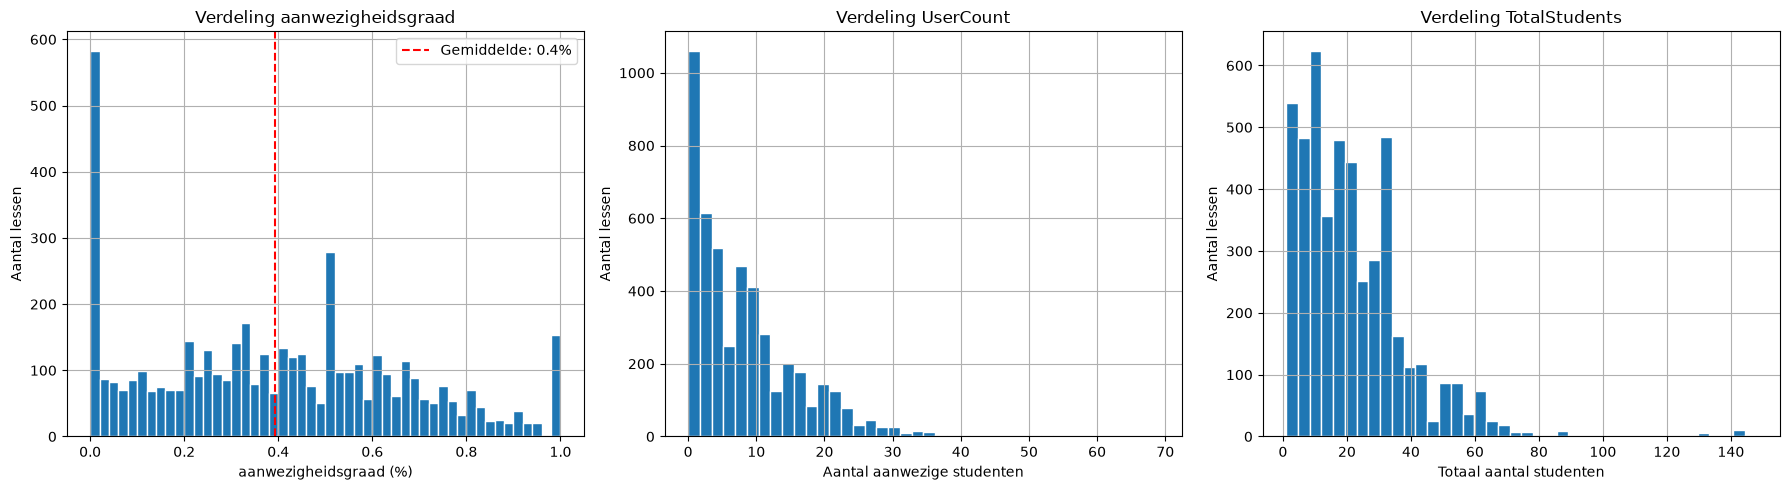

In [32]:
# Verdeling van enkele numerieke variabelen

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Aanwezigheidsgraad

train_df["aanwezigheidsgraad"].hist(
    bins=50,
    ax=axes[0],
    edgecolor="white"
)

axes[0].set_title("Verdeling aanwezigheidsgraad")
axes[0].set_xlabel("aanwezigheidsgraad (%)")
axes[0].set_ylabel("Aantal lessen")

gemiddelde = train_df["aanwezigheidsgraad"].mean()

axes[0].axvline(
    gemiddelde,
    color="red",
    linestyle="--",
    label=f"Gemiddelde: {gemiddelde:.1f}%"
)

axes[0].legend()

# Plot 2: UserCount

train_df["UserCount"].hist(
    bins=40,
    ax=axes[1],
    edgecolor="white"
)

axes[1].set_title("Verdeling UserCount")
axes[1].set_xlabel("Aantal aanwezige studenten")
axes[1].set_ylabel("Aantal lessen")

# Plot 3: TotalStudents

train_df["TotalStudents"].hist(
    bins=40,
    ax=axes[2],
    edgecolor="white"
)

axes[2].set_title("Verdeling TotalStudents")
axes[2].set_xlabel("Totaal aantal studenten")
axes[2].set_ylabel("Aantal lessen")

plt.tight_layout()
plt.show()

**3.6.6 Observatie plot**
* De aanwezigheid verschilt sterk tussen de lessen. Zowel zeer lage als zeer hoge aanwezigheidsgraden komen voor, waardoor de targetvariabele voldoende variatie bevat om een voorspellend model op te bouwen.
* De meeste lessen vinden plaats in relatief kleine groepen. Grote groepen komen minder frequent voor.
* Omdat de groepsgrootte sterk varieert, is de aanwezigheidsgraad een geschiktere targetvariabele dan de absolute UserCount. Hierdoor kunnen lessen met verschillende groepsgroottes eerlijk met elkaar worden vergeleken.

In [33]:
print((train_df["aanwezigheidsgraad"] == 0).sum())
print(train_df[train_df["aanwezigheidsgraad"] == 0][["LectureID", "UserCount", "TotalStudents"]].head(20))

controle = (
    train_df.groupby("LectureID")["UserCount"]
    .apply(lambda x: (x == 0).all())
)

print(f"Lessen waarbij alle subgroepen nog UserCount = 0 hebben: {controle.sum()}")

573
      LectureID  UserCount  TotalStudents
861      473789        0.0              3
867      473787        0.0              3
870      473788        0.0              3
873      473785        0.0              3
876      473786        0.0              3
879      473783        0.0              3
882      473784        0.0              3
888      473782        0.0              3
909      470501        0.0             10
997      323204        0.0             23
998      323204        0.0             22
999      323204        0.0             22
1640     425077        0.0              1
1642     425078        0.0              2
1645     425079        0.0              2
1651     425077        0.0              2
1833     430061        0.0             34
1847     428502        0.0              9
1886     419561        0.0              1
1889     419851        0.0              1
Lessen waarbij alle subgroepen nog UserCount = 0 hebben: 0


**3.6.7 CorrelatieMatrix alle numerieke waarden**
* De aanwezigheid verschilt sterk tussen de lessen. Zowel zeer lage als zeer hoge aanwezigheidsgraden komen voor, waardoor de targetvariabele voldoende variatie bevat om een voorspellend model op te bouwen.
* De meeste lessen vinden plaats in relatief kleine groepen. Grote groepen komen minder frequent voor.
* Omdat de groepsgrootte sterk varieert, is de aanwezigheidsgraad een geschiktere targetvariabele dan de absolute UserCount. Hierdoor kunnen lessen met verschillende groepsgroottes eerlijk met elkaar worden vergeleken.

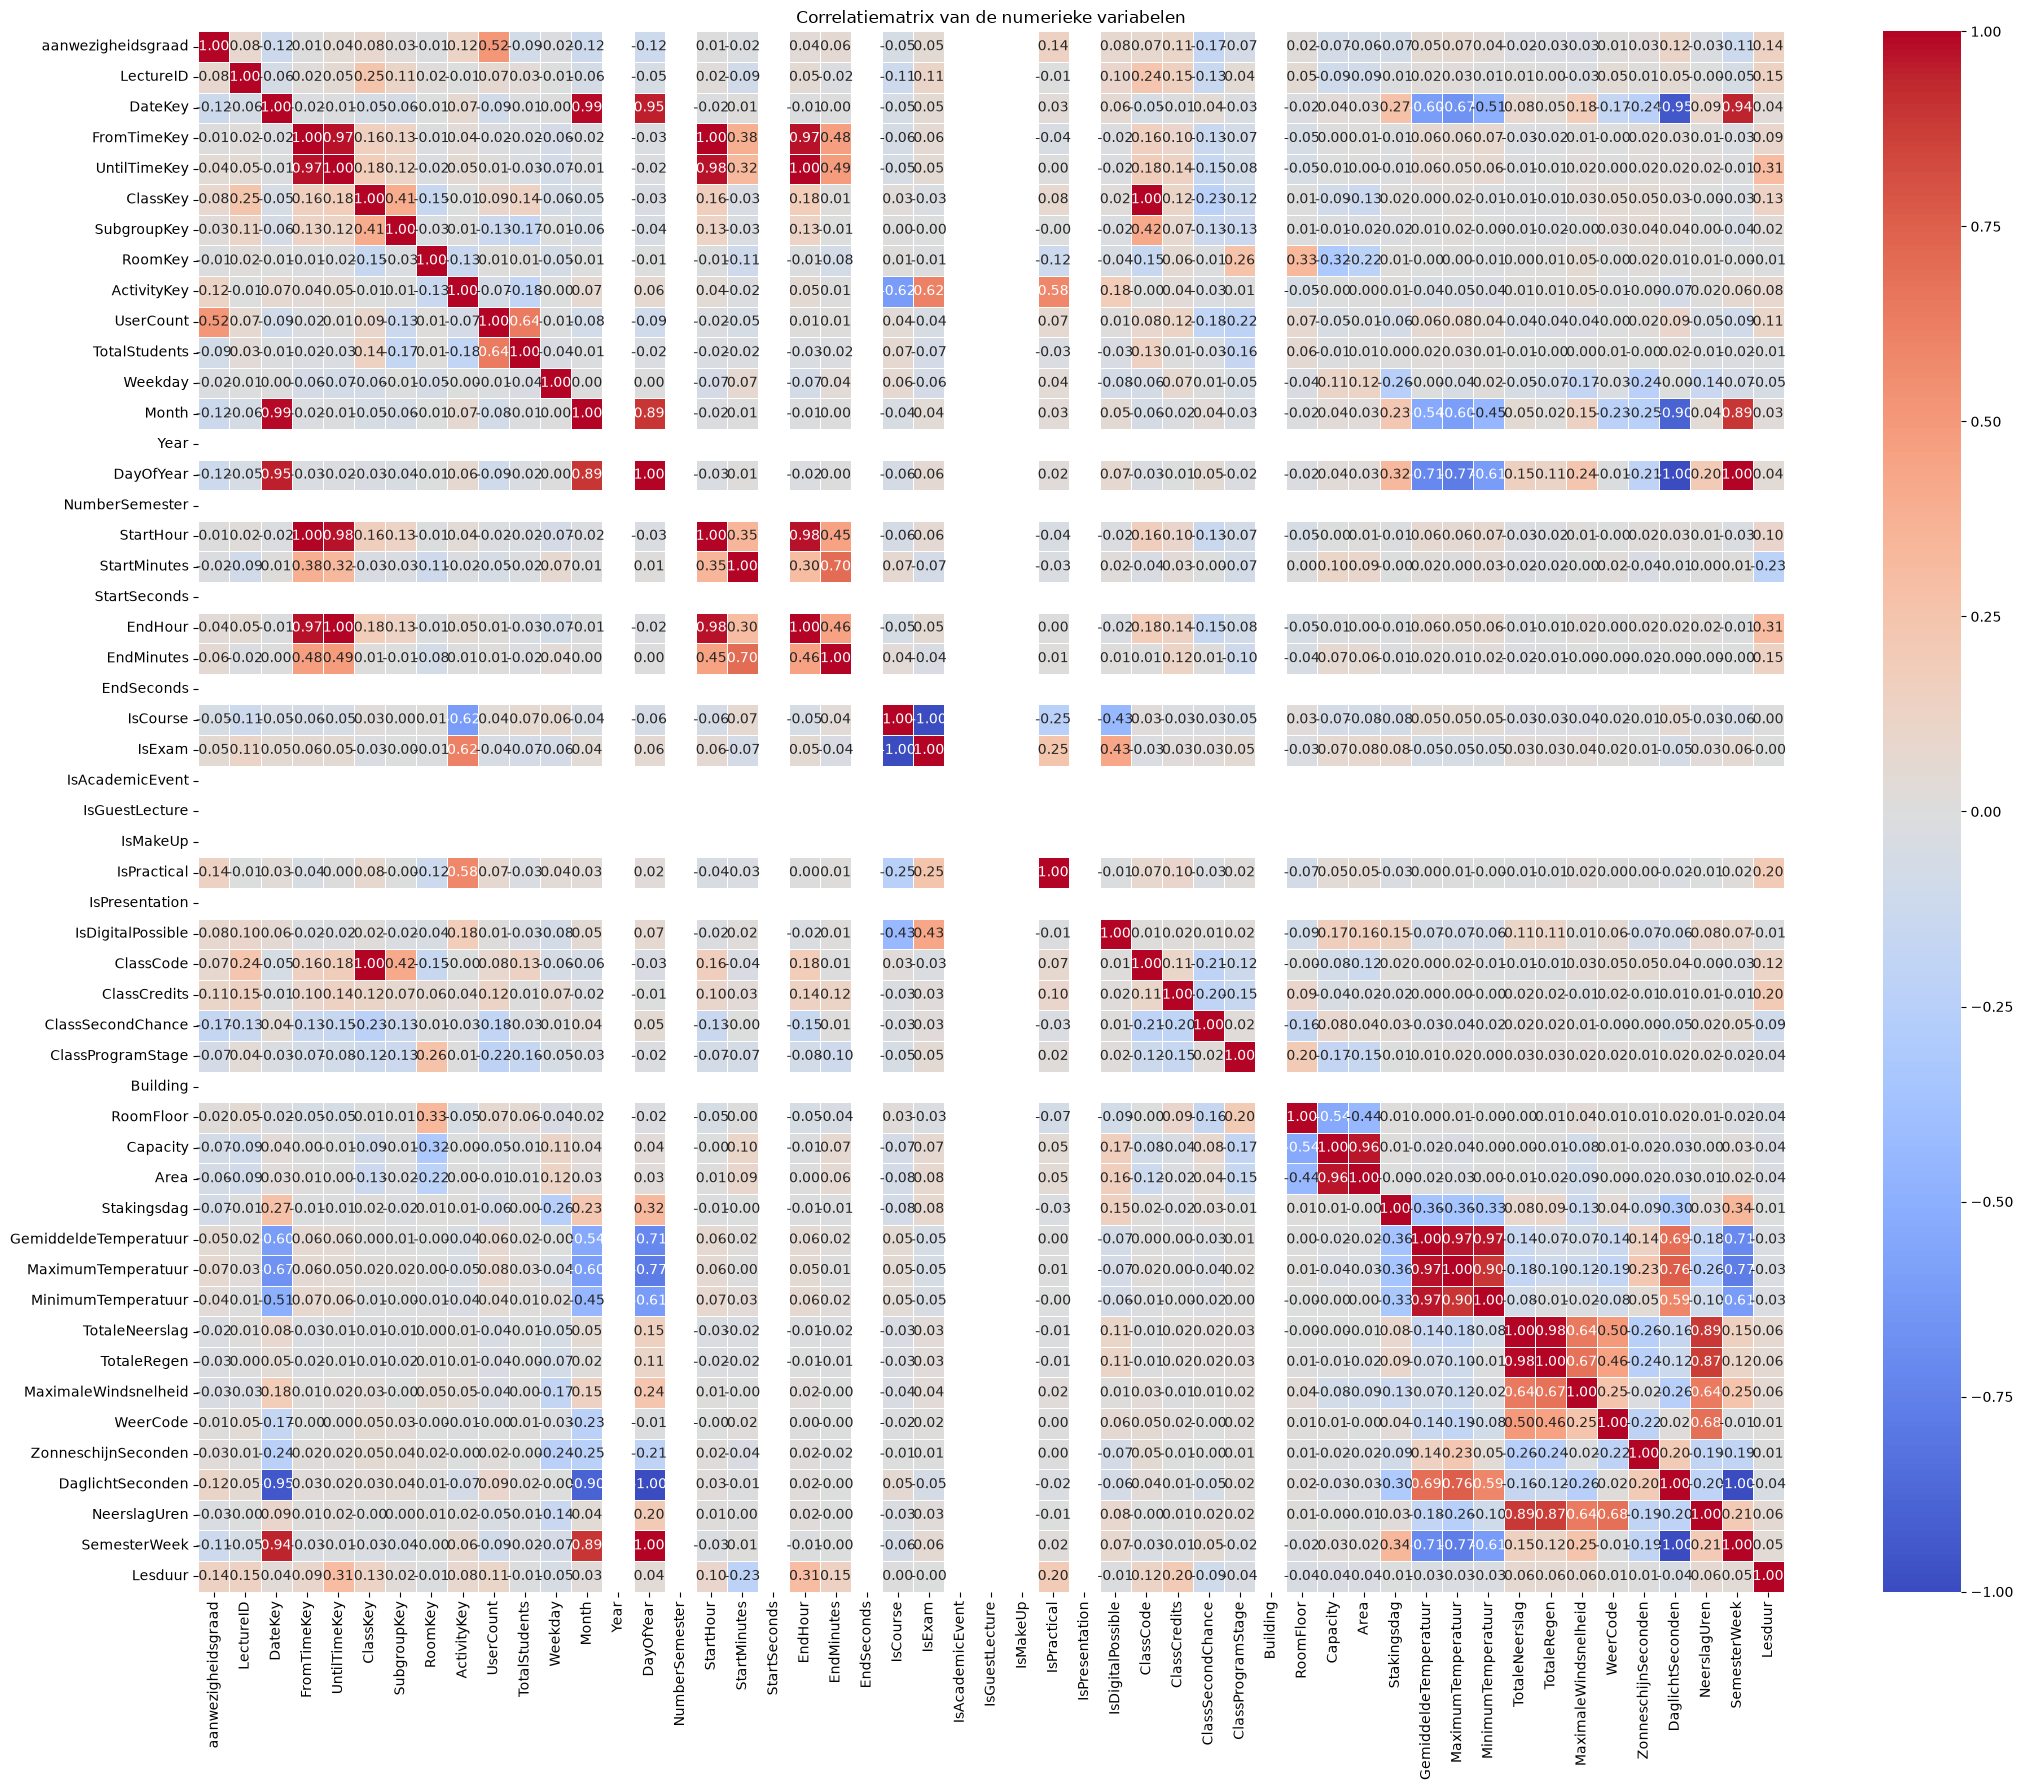

In [34]:
# Correlatiematrix van alle numerieke variabelen

import seaborn as sns

numerieke_data = train_df.select_dtypes(include="number")

# Aanwezigheidsgraad als eerste kolom zetten
kolommen = ["aanwezigheidsgraad"] + [
    kolom for kolom in numerieke_data.columns
    if kolom != "aanwezigheidsgraad"
]

numerieke_data = numerieke_data[kolommen]

# Correlatiematrix berekenen
correlatie_matrix = numerieke_data.corr()

plt.figure(figsize=(22, 18))

sns.heatmap(
    correlatie_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    linewidths=0.5
)

plt.title("Correlatiematrix van de numerieke variabelen")
plt.tight_layout()
plt.show()

In [35]:
# Correlaties met aanwezigheidsgraad

correlaties_aanwezigheid = (
    correlatie_matrix["aanwezigheidsgraad"]
    .sort_values(ascending=False)
)

print("Correlaties met aanwezigheidsgraad:")
print(correlaties_aanwezigheid.round(3))

Correlaties met aanwezigheidsgraad:
aanwezigheidsgraad       1.000
UserCount                0.515
Lesduur                  0.145
IsPractical              0.137
ActivityKey              0.123
DaglichtSeconden         0.116
ClassCredits             0.106
LectureID                0.083
ClassKey                 0.081
IsDigitalPossible        0.076
ClassCode                0.073
MaximumTemperatuur       0.070
EndMinutes               0.059
GemiddeldeTemperatuur    0.053
IsExam                   0.051
UntilTimeKey             0.040
EndHour                  0.038
MinimumTemperatuur       0.035
ZonneschijnSeconden      0.027
SubgroupKey              0.026
RoomFloor                0.020
WeerCode                 0.014
StartHour                0.006
FromTimeKey              0.005
RoomKey                 -0.012
Weekday                 -0.020
StartMinutes            -0.021
TotaleNeerslag          -0.024
TotaleRegen             -0.025
NeerslagUren            -0.030
MaximaleWindsnelheid    -0.032
IsC

**3.6.8 CorrelatieMatrix alle numerieke waarden**
* De meeste numerieke variabelen hebben een zwakke correlatie met de aanwezigheidsgraad. Er is dus geen enkele onafhankelijke numerieke variabele die op zichzelf een sterk lineair verband met de aanwezigheid vertoont.
* `UserCount` heeft met 0,515 de sterkste positieve correlatie. Dit is logisch omdat UserCount rechtstreeks gebruikt wordt om de aanwezigheidsgraad te berekenen en wordt daarom niet als een onafhankelijke verklaring beschouwd.
* `Lesduur` heeft met 0,145 de hoogste positieve correlatie van de overige variabelen. Het verband blijft echter zwak.
* `ClassSecondChance` vertoont met -0,169 de sterkste negatieve correlatie. Dit kan erop wijzen dat de aanwezigheid later in het semester lager wordt en is interessant om verder te onderzoeken.
* Ook tijdskenmerken zoals `Month` (**-0,124**), `DayOfYear` (**-0,115**) en `SemesterWeek` (**-0,114**) vertonen een zwak negatief verband. Dit kan erop wijzen dat de aanwezigheid later in het semester gemiddeld iets lager ligt.
* De verschillende weersvariabelen hebben slechts zeer zwakke correlaties. Op basis van deze correlatiematrix lijkt het weer dus geen sterk lineair verband te hebben met de aanwezigheidsgraad.
* Stakingsdag heeft een kleine negatieve correlatie van -0,073, wat erop wijst dat de aanwezigheid op stakingsdagen gemiddeld iets lager kan liggen.
* Omdat de afzonderlijke correlaties overwegend zwak zijn, is het interessant om vervolgens ook categorische variabelen en mogelijke niet-lineaire verbanden verder te onderzoeken met grafieken.

**3.6.6 Observaties categorische variabelen & mogelijk niet-lineaire verbanden**


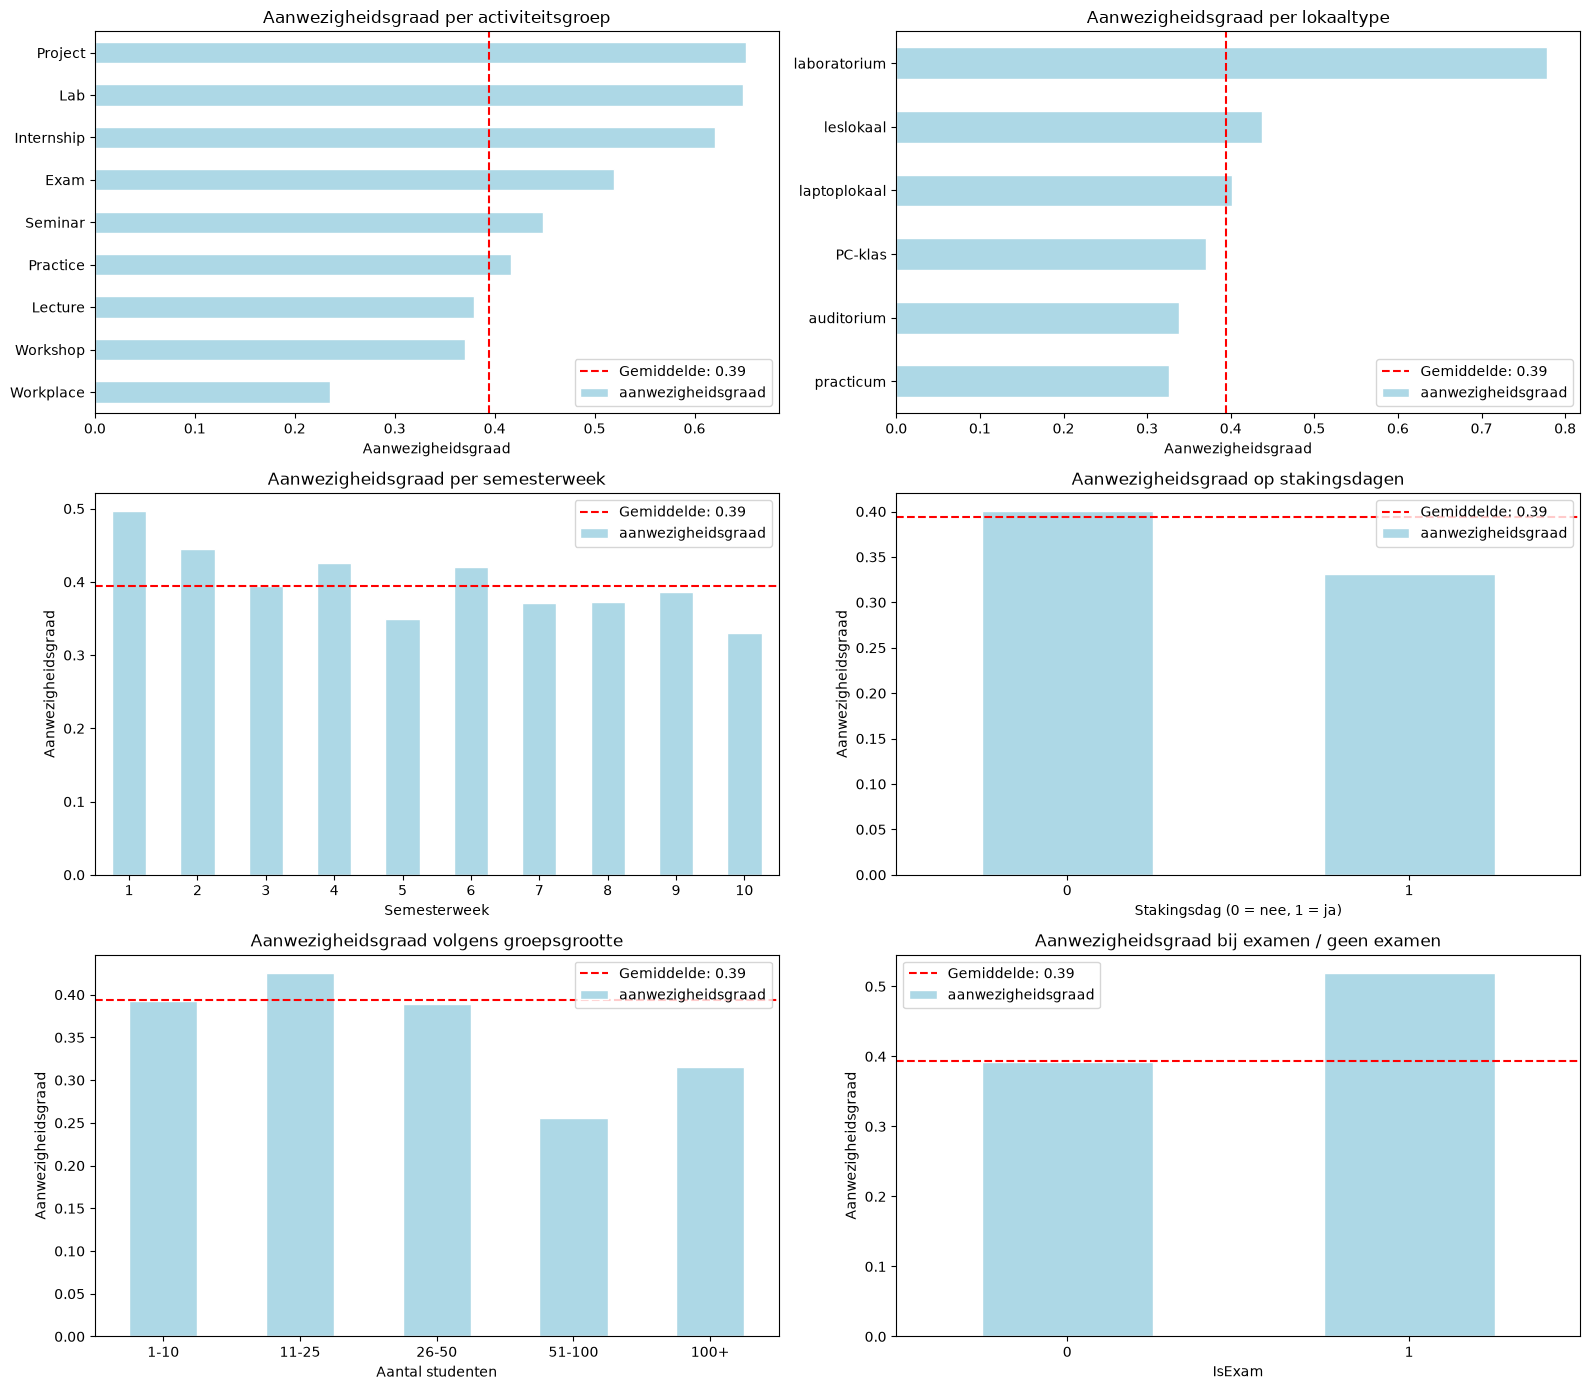

In [36]:
gemiddelde = train_df["aanwezigheidsgraad"].mean()

fig, axes = plt.subplots(3, 2, figsize=(16, 14))


# 1. Aanwezigheidsgraad per activiteitsgroep

train_df.groupby("ActivityGroup")["aanwezigheidsgraad"] \
    .mean() \
    .dropna() \
    .sort_values() \
    .plot(
        kind="barh",
        ax=axes[0, 0],
        color="lightblue",
        edgecolor="white"
    )

axes[0, 0].axvline(
    gemiddelde,
    color="red",
    linestyle="--",
    label=f"Gemiddelde: {gemiddelde:.2f}"
)

axes[0, 0].set_title("Aanwezigheidsgraad per activiteitsgroep")
axes[0, 0].set_xlabel("Aanwezigheidsgraad")
axes[0, 0].set_ylabel("")
axes[0, 0].legend()


# 2. Aanwezigheidsgraad per lokaaltype

train_df.groupby("RoomCategory")["aanwezigheidsgraad"] \
    .mean() \
    .dropna() \
    .sort_values() \
    .plot(
        kind="barh",
        ax=axes[0, 1],
        color="lightblue",
        edgecolor="white"
    )

axes[0, 1].axvline(
    gemiddelde,
    color="red",
    linestyle="--",
    label=f"Gemiddelde: {gemiddelde:.2f}"
)

axes[0, 1].set_title("Aanwezigheidsgraad per lokaaltype")
axes[0, 1].set_xlabel("Aanwezigheidsgraad")
axes[0, 1].set_ylabel("")
axes[0, 1].legend()



# 3. Aanwezigheidsgraad per semesterweek

train_df.groupby("SemesterWeek")["aanwezigheidsgraad"] \
    .mean() \
    .plot(
        kind="bar",
        ax=axes[1, 0],
        color="lightblue",
        edgecolor="white"
    )

axes[1, 0].axhline(
    gemiddelde,
    color="red",
    linestyle="--",
    label=f"Gemiddelde: {gemiddelde:.2f}"
)

axes[1, 0].set_title("Aanwezigheidsgraad per semesterweek")
axes[1, 0].set_xlabel("Semesterweek")
axes[1, 0].set_ylabel("Aanwezigheidsgraad")
axes[1, 0].tick_params(axis="x", rotation=0)
axes[1, 0].legend()


# 4. Aanwezigheidsgraad op stakingsdagen

train_df.groupby("Stakingsdag")["aanwezigheidsgraad"] \
    .mean() \
    .plot(
        kind="bar",
        ax=axes[1, 1],
        color="lightblue",
        edgecolor="white"
    )

axes[1, 1].axhline(
    gemiddelde,
    color="red",
    linestyle="--",
    label=f"Gemiddelde: {gemiddelde:.2f}"
)

axes[1, 1].set_title("Aanwezigheidsgraad op stakingsdagen")
axes[1, 1].set_xlabel("Stakingsdag (0 = nee, 1 = ja)")
axes[1, 1].set_ylabel("Aanwezigheidsgraad")
axes[1, 1].tick_params(axis="x", rotation=0)
axes[1, 1].legend()


# 5. Aanwezigheidsgraad volgens groepsgrootte

train_df["Groepsgrootte"] = pd.cut(
    train_df["TotalStudents"],
    bins=[0, 10, 25, 50, 100, float("inf")],
    labels=["1-10", "11-25", "26-50", "51-100", "100+"]
)

train_df.groupby(
    "Groepsgrootte",
    observed=True
)["aanwezigheidsgraad"].mean().plot(
    kind="bar",
    ax=axes[2, 0],
    color="lightblue",
    edgecolor="white"
)

axes[2, 0].axhline(
    gemiddelde,
    color="red",
    linestyle="--",
    label=f"Gemiddelde: {gemiddelde:.2f}"
)

axes[2, 0].set_title("Aanwezigheidsgraad volgens groepsgrootte")
axes[2, 0].set_xlabel("Aantal studenten")
axes[2, 0].set_ylabel("Aanwezigheidsgraad")
axes[2, 0].tick_params(axis="x", rotation=0)
axes[2, 0].legend()


# 6. Aanwezigheidsgraad bij examen / geen examen

train_df.groupby("IsExam")["aanwezigheidsgraad"] \
    .mean() \
    .plot(
        kind="bar",
        ax=axes[2, 1],
        color="lightblue",
        edgecolor="white"
    )

axes[2, 1].axhline(
    gemiddelde,
    color="red",
    linestyle="--",
    label=f"Gemiddelde: {gemiddelde:.2f}"
)

axes[2, 1].set_title("Aanwezigheidsgraad bij examen / geen examen")
axes[2, 1].set_xlabel("IsExam")
axes[2, 1].set_ylabel("Aanwezigheidsgraad")
axes[2, 1].tick_params(axis="x", rotation=0)
axes[2, 1].legend()


plt.tight_layout()
plt.show()

In [37]:
print("Gemiddelde aanwezigheidsgraad per activiteitstype:")
print(
    train_df.groupby("CanonicalActivity")["aanwezigheidsgraad"]
    .mean()
    .sort_values()
    .round(3)
)


Gemiddelde aanwezigheidsgraad per activiteitstype:
CanonicalActivity
Werkplekleren                0.235
Examen (vaardigheidstest)    0.361
Begeleiding                  0.370
Activerend hoorcollege       0.379
Oefensessie                  0.416
Onderwijsleergesprek         0.448
Examen (schriftelijk)        0.565
Stage                        0.620
Practicum                    0.649
Werken aan opdracht          0.652
Examen (digitaal)            0.825
Name: aanwezigheidsgraad, dtype: float64


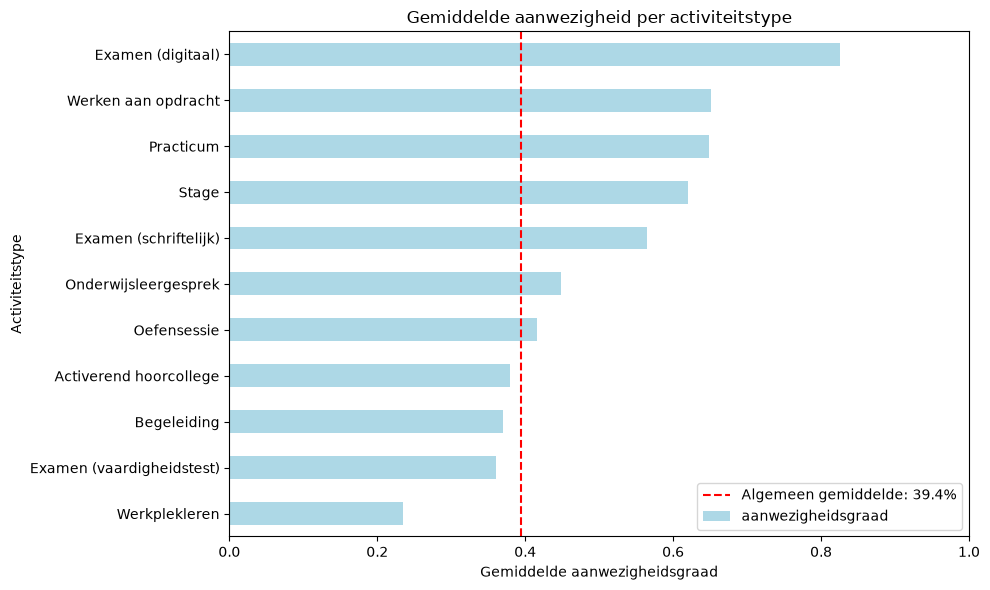

In [38]:
# Gemiddelde aanwezigheid per activiteitstype

gem_activiteit = (
    train_df.groupby("CanonicalActivity")["aanwezigheidsgraad"]
    .mean()
    .sort_values()
)

# Algemeen gemiddelde aanwezigheidsgraad
gemiddelde_aanwezigheid = train_df["aanwezigheidsgraad"].mean()

ax = gem_activiteit.plot(
    kind="barh",
    figsize=(10, 6),
    color="lightblue"
)

# Rode lijn voor algemeen gemiddelde
ax.axvline(
    gemiddelde_aanwezigheid,
    color="red",
    linestyle="--",
    label=f"Algemeen gemiddelde: {gemiddelde_aanwezigheid:.1%}"
)

plt.title("Gemiddelde aanwezigheid per activiteitstype")
plt.xlabel("Gemiddelde aanwezigheidsgraad")
plt.ylabel("Activiteitstype")

plt.xlim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

**3.6.9 Conclusie observatie categorische variabelen**
* Er zijn duidelijke verschillen tussen de activiteitsgroepen. Project en Lab hebben de hoogste gemiddelde aanwezigheidsgraad, terwijl Workplace duidelijk de laagste aanwezigheid heeft. Ook Lecture en Workshop liggen onder het algemene gemiddelde.
* Het type lokaal lijkt eveneens samen te hangen met de aanwezigheid. Lessen in een laboratorium hebben met ongeveer 80% een opvallend hoge gemiddelde aanwezigheid. practicum, auditorium en PC-klas liggen daarentegen onder het algemene gemiddelde. Hierbij moeten we wel rekening houden met het aantal lessen dat binnen elk lokaaltype voorkomt.
* De aanwezigheid lijkt gedurende het semester af te nemen. In semesterweek 1 ligt de gemiddelde aanwezigheid nog rond 50%, terwijl deze in week 10 rond 33% ligt. De daling is niet volledig lineair, want bijvoorbeeld in week 6 stijgt de aanwezigheid opnieuw.
* Op stakingsdagen ligt de gemiddelde aanwezigheid duidelijk lager: ongeveer 33% tegenover 40% op gewone dagen. Dit ondersteunt de eerdere vaststelling uit de correlatiematrix dat Stakingsdag een negatief verband heeft met de aanwezigheidsgraad.
* Bij de groepsgrootte zien we dat groepen van 11–25 studenten de hoogste gemiddelde aanwezigheid hebben. Vanaf ongeveer 50 studenten lijkt de aanwezigheid duidelijk lager te liggen. De groep 51–100 heeft de laagste gemiddelde aanwezigheid.
* Bij examens ligt de gemiddelde aanwezigheid duidelijk hoger dan bij niet-examens: ongeveer 52% tegenover 40%. IsExam kan daardoor een interessante variabele zijn om later mee te nemen in het model.
* De gemiddelde aanwezigheid verschilt duidelijk per activiteitstype. Digitale examens, practica en stages liggen ruim boven het algemene gemiddelde van 39,4%.

**3.6.10 Conclusie aanwezigheidsgraad**

De grafieken tonen iets belangrijks dat we in de correlatiematrix niet volledig konden zien: hoewel de meeste afzonderlijke numerieke correlaties met aanwezigheidsgraad zwak waren, zijn er wel duidelijke verschillen tussen bepaalde groepen en categorieën.

Vooral activiteitstype, lokaaltype, semesterweek, stakingsdagen, groepsgrootte en examens lijken interessant om verder mee te nemen.



**3.6.11 Weer vs Aanwezigheidsgraad**

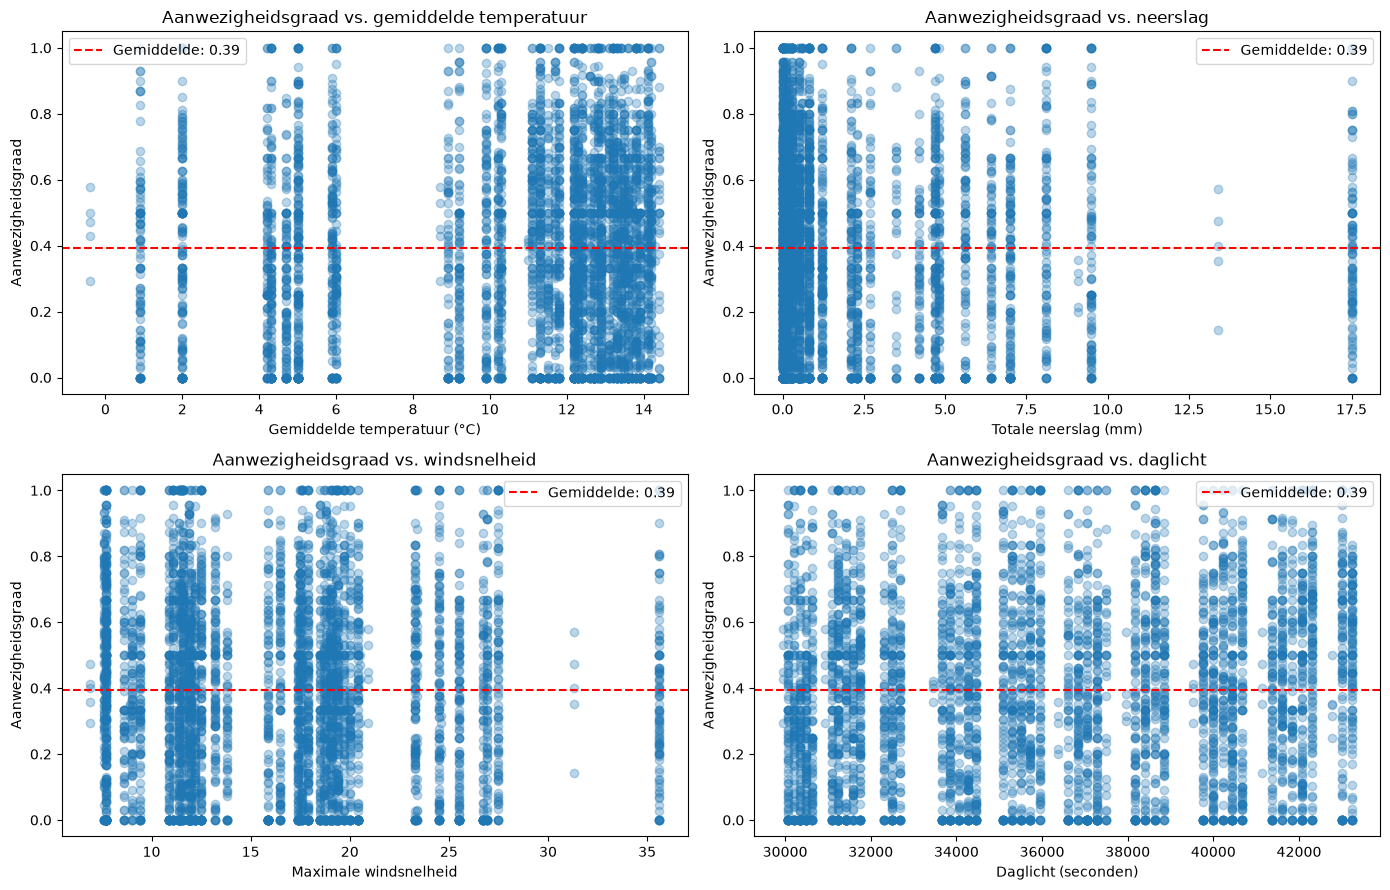

In [39]:
gemiddelde = train_df["aanwezigheidsgraad"].mean()

fig, axes = plt.subplots(2, 2, figsize=(14, 9))


# Gemiddelde temperatuur

axes[0, 0].scatter(
    train_df["GemiddeldeTemperatuur"],
    train_df["aanwezigheidsgraad"],
    alpha=0.3
)

axes[0, 0].axhline(
    gemiddelde,
    color="red",
    linestyle="--",
    label=f"Gemiddelde: {gemiddelde:.2f}"
)

axes[0, 0].set_title("Aanwezigheidsgraad vs. gemiddelde temperatuur")
axes[0, 0].set_xlabel("Gemiddelde temperatuur (°C)")
axes[0, 0].set_ylabel("Aanwezigheidsgraad")
axes[0, 0].legend()


# Totale neerslag

axes[0, 1].scatter(
    train_df["TotaleNeerslag"],
    train_df["aanwezigheidsgraad"],
    alpha=0.3
)

axes[0, 1].axhline(
    gemiddelde,
    color="red",
    linestyle="--",
    label=f"Gemiddelde: {gemiddelde:.2f}"
)

axes[0, 1].set_title("Aanwezigheidsgraad vs. neerslag")
axes[0, 1].set_xlabel("Totale neerslag (mm)")
axes[0, 1].set_ylabel("Aanwezigheidsgraad")
axes[0, 1].legend()


# Maximale windsnelheid

axes[1, 0].scatter(
    train_df["MaximaleWindsnelheid"],
    train_df["aanwezigheidsgraad"],
    alpha=0.3
)

axes[1, 0].axhline(
    gemiddelde,
    color="red",
    linestyle="--",
    label=f"Gemiddelde: {gemiddelde:.2f}"
)

axes[1, 0].set_title("Aanwezigheidsgraad vs. windsnelheid")
axes[1, 0].set_xlabel("Maximale windsnelheid")
axes[1, 0].set_ylabel("Aanwezigheidsgraad")
axes[1, 0].legend()


# Daglicht

axes[1, 1].scatter(
    train_df["DaglichtSeconden"],
    train_df["aanwezigheidsgraad"],
    alpha=0.3
)

axes[1, 1].axhline(
    gemiddelde,
    color="red",
    linestyle="--",
    label=f"Gemiddelde: {gemiddelde:.2f}"
)

axes[1, 1].set_title("Aanwezigheidsgraad vs. daglicht")
axes[1, 1].set_xlabel("Daglicht (seconden)")
axes[1, 1].set_ylabel("Aanwezigheidsgraad")
axes[1, 1].legend()


plt.tight_layout()
plt.show()

**3.6.12 Conclusie weer vs aanwezigheidsgraad**

* De scatterplots tonen geen sterk verband tussen de weersomstandigheden en de aanwezigheidsgraad. De punten liggen bij vrijwel alle weerswaarden sterk verspreid.
* Bij de gemiddelde temperatuur lijkt de aanwezigheid licht toe te nemen bij hogere temperaturen, maar het verband is zwak.
* Voor neerslag en windsnelheid is geen duidelijk patroon zichtbaar. Zowel hoge als lage aanwezigheid komt voor bij verschillende weersomstandigheden.
* Ook bij daglicht is de spreiding groot. Hoewel daglicht in de correlatiematrix een kleine positieve correlatie vertoonde, is er in de scatterplot geen sterk lineair patroon zichtbaar.
* We kunnen daarom voorlopig besluiten dat het weer op zichzelf geen sterke voorspeller van de aanwezigheidsgraad lijkt te zijn. Het kan later wel in combinatie met andere kenmerken nuttig zijn voor het model.

**3.6.13 Extra leuke categorische variabelen**

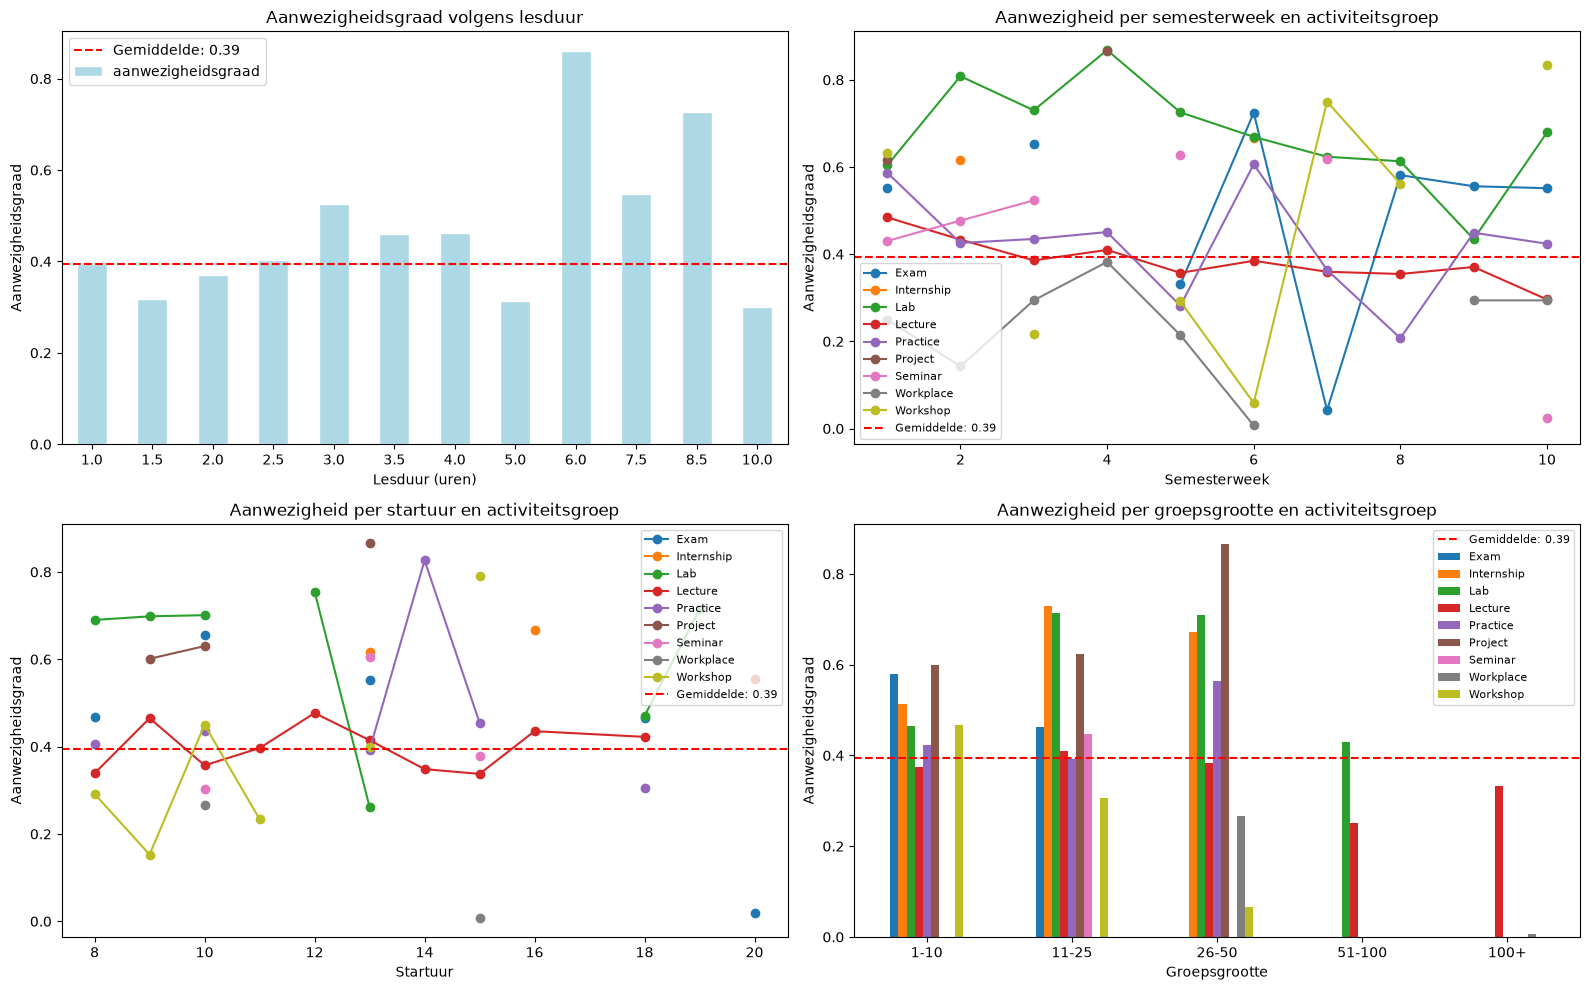

In [40]:
# Extra onderzoek naar factoren die de aanwezigheid kunnen beïnvloeden

# ------------------------------------------------------------
# Nieuwe variabele: lesduur berekenen
# ------------------------------------------------------------

train_df["Lesduur"] = (
    (train_df["EndHour"] * 60 + train_df["EndMinutes"])
    - (train_df["StartHour"] * 60 + train_df["StartMinutes"])
) / 60

# Afronden op halve uren om de grafiek overzichtelijk te houden
train_df["Lesduur"] = (train_df["Lesduur"] * 2).round() / 2


# Gemiddelde aanwezigheidsgraad
gemiddelde = train_df["aanwezigheidsgraad"].mean()


# ------------------------------------------------------------
# Grafieken maken
# ------------------------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(16, 10))


# 1. Aanwezigheidsgraad volgens lesduur

train_df.groupby("Lesduur")["aanwezigheidsgraad"].mean().plot(
    kind="bar",
    ax=axes[0, 0],
    color="lightblue",
    edgecolor="white"
)

axes[0, 0].axhline(
    gemiddelde,
    color="red",
    linestyle="--",
    label=f"Gemiddelde: {gemiddelde:.2f}"
)

axes[0, 0].set_title("Aanwezigheidsgraad volgens lesduur")
axes[0, 0].set_xlabel("Lesduur (uren)")
axes[0, 0].set_ylabel("Aanwezigheidsgraad")
axes[0, 0].tick_params(axis="x", rotation=0)
axes[0, 0].legend()


# 2. Aanwezigheidsgraad per semesterweek en activiteitsgroep

overzicht_week = train_df.pivot_table(
    values="aanwezigheidsgraad",
    index="SemesterWeek",
    columns="ActivityGroup",
    aggfunc="mean"
)

overzicht_week.plot(
    ax=axes[0, 1],
    marker="o"
)

axes[0, 1].axhline(
    gemiddelde,
    color="red",
    linestyle="--",
    label=f"Gemiddelde: {gemiddelde:.2f}"
)

axes[0, 1].set_title("Aanwezigheid per semesterweek en activiteitsgroep")
axes[0, 1].set_xlabel("Semesterweek")
axes[0, 1].set_ylabel("Aanwezigheidsgraad")
axes[0, 1].legend(fontsize=8)


# 3. Aanwezigheidsgraad per startuur en activiteitsgroep

overzicht_uur = train_df.pivot_table(
    values="aanwezigheidsgraad",
    index="StartHour",
    columns="ActivityGroup",
    aggfunc="mean"
)

overzicht_uur.plot(
    ax=axes[1, 0],
    marker="o"
)

axes[1, 0].axhline(
    gemiddelde,
    color="red",
    linestyle="--",
    label=f"Gemiddelde: {gemiddelde:.2f}"
)

axes[1, 0].set_title("Aanwezigheid per startuur en activiteitsgroep")
axes[1, 0].set_xlabel("Startuur")
axes[1, 0].set_ylabel("Aanwezigheidsgraad")
axes[1, 0].legend(fontsize=8)


# 4. Aanwezigheidsgraad per groepsgrootte en activiteitsgroep

overzicht_groep = train_df.pivot_table(
    values="aanwezigheidsgraad",
    index="Groepsgrootte",
    columns="ActivityGroup",
    aggfunc="mean",
    observed=True
)

overzicht_groep.plot(
    kind="bar",
    ax=axes[1, 1]
)

axes[1, 1].axhline(
    gemiddelde,
    color="red",
    linestyle="--",
    label=f"Gemiddelde: {gemiddelde:.2f}"
)

axes[1, 1].set_title("Aanwezigheid per groepsgrootte en activiteitsgroep")
axes[1, 1].set_xlabel("Groepsgrootte")
axes[1, 1].set_ylabel("Aanwezigheidsgraad")
axes[1, 1].tick_params(axis="x", rotation=0)
axes[1, 1].legend(fontsize=8)


plt.tight_layout()
plt.show()

In [41]:
# ============================================================
# CONTROLE VAN OPVALLENDE WAARDEN
# ============================================================


# 1. Hoeveel lessen zitten achter elke lesduur?

print("Aantal lessen per lesduur:\n")

print(
    train_df.groupby("Lesduur")
    .agg(
        AantalLessen=("LectureID", "nunique"),
        AantalRijen=("LectureID", "size"),
        GemiddeldeAanwezigheid=("aanwezigheidsgraad", "mean")
    )
    .round(3)
)


# 2. Examens per semesterweek controleren

print("\nAantal examens per semesterweek:\n")

examens = train_df[train_df["IsExam"] == 1]

print(
    examens.groupby("SemesterWeek")
    .agg(
        AantalExamens=("LectureID", "nunique"),
        AantalRijen=("LectureID", "size"),
        GemiddeldeAanwezigheid=("aanwezigheidsgraad", "mean")
    )
    .round(3)
)


# 3. Welke examens zijn dit precies?

print("\nExamens in de trainset:\n")

print(
    examens[
        [
            "FullDate",
            "SemesterWeek",
            "LectureID",
            "CanonicalActivity",
            "ActivityGroup",
            "ClassName",
            "ProgramName",
            "StartTime",
            "EndTime"
        ]
    ]
    .drop_duplicates()
    .sort_values(["FullDate", "StartTime"])
    .to_string(index=False)
)

Aantal lessen per lesduur:

         AantalLessen  AantalRijen  GemiddeldeAanwezigheid
Lesduur                                                   
1.0               132          228                   0.395
1.5                46           83                   0.319
2.0              1723         3614                   0.371
2.5                18           18                   0.404
3.0               339          509                   0.526
3.5                76           98                   0.460
4.0                83          157                   0.462
5.0                 2            6                   0.314
6.0                 2            8                   0.861
7.5                 5           10                   0.548
8.5                 1            1                   0.727
10.0                1            1                   0.300

Aantal examens per semesterweek:

              AantalExamens  AantalRijen  GemiddeldeAanwezigheid
SemesterWeek                                  

**3.6.15 Observaties extra onderzoek**


* De lesduur lijkt geen eenvoudig lineair verband te hebben met de aanwezigheidsgraad. Lessen van 3 uur hebben bijvoorbeeld een hogere gemiddelde aanwezigheidsgraad (ongeveer 53%) dan lessen van 2 uur (ongeveer 37%). De meeste lessen duren 2 uur (1.723 lessen), waardoor deze categorie veel representatiever is.
* De opvallend hoge aanwezigheid bij sommige lange lessen moet voorzichtig geïnterpreteerd worden. Er zijn bijvoorbeeld slechts 2 lessen van 6 uur, 1 les van 8,5 uur en 1 les van 10 uur. Deze waarden zijn dus gebaseerd op zeer weinig lessen.
* De aanwezigheid per semesterweek verschilt sterk per activiteitsgroep. Vooral Lab ligt gedurende meerdere weken duidelijk boven het algemene gemiddelde. Bij Lecture blijft de aanwezigheid stabieler en meestal rond het algemene gemiddelde.
* Het effect van het startuur verschilt per activiteitsgroep. Er is geen startuur dat voor alle soorten lessen duidelijk een hogere of lagere aanwezigheid geeft. Dit sluit aan bij de correlatiematrix, waar StartHour bijna geen lineair verband met de aanwezigheidsgraad vertoonde.
* Ook bij de groepsgrootte zien we verschillen tussen de activiteitsgroepen. Lab en Internship hebben bij kleinere en middelgrote groepen relatief hoge aanwezigheidsgraden, terwijl Lecture meestal rond of onder het algemene gemiddelde ligt.
* Niet iedere activiteitsgroep komt voor bij iedere groepsgrootte, semesterweek of ieder startuur. Sommige opvallend hoge of lage waarden kunnen daarom gebaseerd zijn op een klein aantal lessen en moeten voorzichtig geïnterpreteerd worden.

**3.6.16 Deepdive in examens lw: 1/2/3**


In [42]:
# Controle van examens in semesterweek 1 en 3

vroege_examens = train_df[
    (train_df["IsExam"] == 1) &
    (train_df["SemesterWeek"].isin([1, 3]))
]

print(
    vroege_examens[
        [
            "FullDate",
            "SemesterWeek",
            "LectureID",
            "CanonicalActivity",
            "ClassName",
            "ProgramName",
            "StartTime",
            "EndTime",
            "UserCount",
            "TotalStudents",
            "aanwezigheidsgraad"
        ]
    ]
    .sort_values(["FullDate", "LectureID"])
    .to_string(index=False)
)

  FullDate  SemesterWeek  LectureID         CanonicalActivity       ClassName   ProgramName StartTime  EndTime  UserCount  TotalStudents  aanwezigheidsgraad
2025-09-26             1     433085     Examen (schriftelijk)           Stage    PBA-VG-LAM  13:30:00 16:30:00       10.0             18            0.555556
2025-09-26             1     433085     Examen (schriftelijk)           Stage    PBA-VG-LAM  13:30:00 16:30:00       15.0             23            0.652174
2025-09-26             1     433085     Examen (schriftelijk)           Stage    PBA-VG-LAM  13:30:00 16:30:00        1.0              1            1.000000
2025-09-26             1     433085     Examen (schriftelijk)           Stage    PBA-VG-LAM  13:30:00 16:30:00        0.0              1            0.000000
2025-10-06             3     471629 Examen (vaardigheidstest) Technisch Frans GRAD-WERF-WON  18:00:00 21:30:00        7.0             13            0.538462
2025-10-06             3     471629 Examen (vaardigheidste

**3.6.17 Observaties examens lw:1/2/3**

Er komen reeds examens voor in de eerste semesterweken. Na controle blijkt dat het om geldige onderwijsactiviteiten gaat. In semesterweek 1 en 3 gaat het telkens om slechts één uniek examen met meerdere subgroepen. Er is daarom geen reden om deze gegevens uit de dataset te verwijderen. Examens worden behouden en kunnen via IsExam en ActivityGroup door het model onderscheiden worden van andere activiteiten.

**3.6.18 IsDigital verkenning**

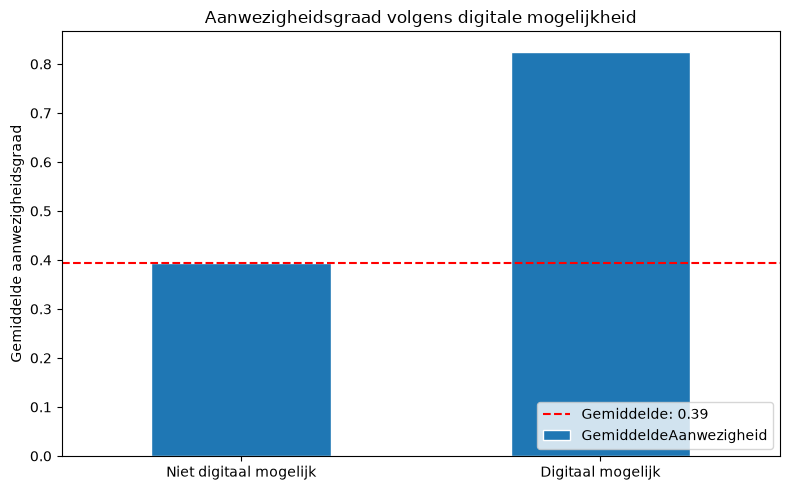

Overzicht digitale mogelijkheid:

                        GemiddeldeAanwezigheid  AantalRijen  AantalLessen
IsDigitalPossible                                                        
Niet digitaal mogelijk                   0.393         4722          2427
Digitaal mogelijk                        0.825           11             1


In [43]:
# Aanwezigheidsgraad volgens mogelijkheid om de activiteit digitaal te volgen

gem = train_df["aanwezigheidsgraad"].mean()

digitaal = (
    train_df.groupby("IsDigitalPossible")
    .agg(
        GemiddeldeAanwezigheid=("aanwezigheidsgraad", "mean"),
        AantalRijen=("LectureID", "size"),
        AantalLessen=("LectureID", "nunique")
    )
)

# Duidelijke labels
digitaal.index = digitaal.index.map({
    0: "Niet digitaal mogelijk",
    1: "Digitaal mogelijk"
})

# Visualisatie
ax = digitaal["GemiddeldeAanwezigheid"].plot(
    kind="bar",
    figsize=(8, 5),
    edgecolor="white"
)

ax.axhline(
    gem,
    color="red",
    linestyle="--",
    label=f"Gemiddelde: {gem:.2f}"
)

ax.set_title("Aanwezigheidsgraad volgens digitale mogelijkheid")
ax.set_xlabel("")
ax.set_ylabel("Gemiddelde aanwezigheidsgraad")
ax.tick_params(axis="x", rotation=0)
ax.legend(loc="lower right")

plt.tight_layout()
plt.show()


# Overzicht
print("Overzicht digitale mogelijkheid:\n")
print(digitaal.round(3))

**4.6.19 IsDigital Conclusie / observatie**


Activiteiten die digitaal gevolgd kunnen worden hebben een veel hogere gemiddelde aanwezigheidsgraad (90,2%) dan activiteiten die niet digitaal gevolgd kunnen worden (39,3%).
Dit verschil is echter niet representatief, omdat IsDigitalPossible = 1 slechts voorkomt bij 6 rijen die allemaal tot 1 unieke les behoren.
Op basis van deze dataset kunnen we daarom niet concluderen dat de mogelijkheid om een les digitaal te volgen invloed heeft op de aanwezigheidsgraad.

In [44]:
print("VOLLEDIGE DATASET")
print(df_merged["IsDigitalPossible"].value_counts(dropna=False))

print("\nTRAINSET")
print(train_df["IsDigitalPossible"].value_counts(dropna=False))

print("\nTESTSET")
print(test_df["IsDigitalPossible"].value_counts(dropna=False))

VOLLEDIGE DATASET
IsDigitalPossible
0    6003
1      11
Name: count, dtype: int64

TRAINSET
IsDigitalPossible
0    4722
1      11
Name: count, dtype: int64

TESTSET
IsDigitalPossible
0    1281
Name: count, dtype: int64


**4.6.20 Verschilt de aanwezigheidsgraad tussen programmafase 1, 2 en 3?**




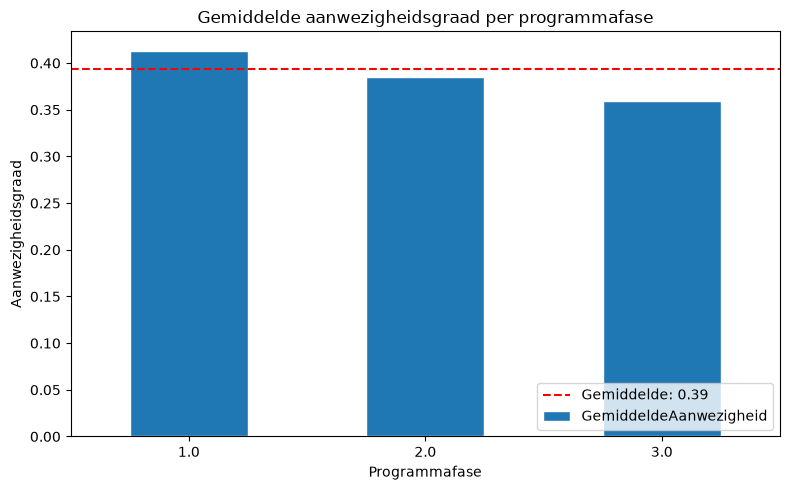

Aanwezigheid per programmafase:

                   GemiddeldeAanwezigheid  AantalRijen  AantalLessen
ClassProgramStage                                                   
1.0                                 0.413         2055          1105
2.0                                 0.385         1862           832
3.0                                 0.359          614           358


In [45]:
# Aanwezigheidsgraad per programmafase

gem = train_df["aanwezigheidsgraad"].mean()

programmafase = (
    train_df
    .dropna(subset=["ClassProgramStage"])
    .groupby("ClassProgramStage")
    .agg(
        GemiddeldeAanwezigheid=("aanwezigheidsgraad", "mean"),
        AantalRijen=("LectureID", "size"),
        AantalLessen=("LectureID", "nunique")
    )
)

# Visualisatie

ax = programmafase["GemiddeldeAanwezigheid"].plot(
    kind="bar",
    figsize=(8, 5),
    edgecolor="white"
)

ax.axhline(
    gem,
    color="red",
    linestyle="--",
    label=f"Gemiddelde: {gem:.2f}"
)

ax.set_title("Gemiddelde aanwezigheidsgraad per programmafase")
ax.set_xlabel("Programmafase")
ax.set_ylabel("Aanwezigheidsgraad")
ax.tick_params(axis="x", rotation=0)
ax.legend(loc="lower right")

plt.tight_layout()
plt.show()


# Overzicht

print("Aanwezigheid per programmafase:\n")
print(programmafase.round(3))

**4.6.20.1 Conclusie aanwezigheidsgraad vs programmafase**

Observatie: De gemiddelde aanwezigheidsgraad neemt af naarmate de programmafase hoger wordt. Programmafase 1 heeft met 41,3% de hoogste gemiddelde aanwezigheid en ligt boven het algemene gemiddelde van ongeveer 38,5%. In programmafase 2 daalt dit naar 35,9% en in programmafase 3 verder naar 34,3%. Dit suggereert dat studenten bij opleidingsonderdelen uit een vroegere programmafase gemiddeld vaker aanwezig zijn. Het gaat hierbij om een verband en niet noodzakelijk om een oorzakelijk effect.

# Fase 4  — Data cleaning

**Doel:** De data cleanen zodat het model enkel relevante en correcte observaties bevat.


**4.1: Beginpunt data**

In [46]:
cleaning_log = []


def log_stap(beschrijving, aantal_voor, aantal_na):
    verwijderd = aantal_voor - aantal_na

    cleaning_log.append({
        "Stap": beschrijving,
        "Rijen voor": aantal_voor,
        "Verwijderd": verwijderd,
        "Rijen na": aantal_na
    })

    print(
        f"{beschrijving}: "
        f"{verwijderd:,} rijen verwijderd, "
        f"{aantal_na:,} rijen over"
    )


# Beginpunt data cleaning

print("BEGINPUNT DATA CLEANING\n")

print(f"Volledige dataset: {len(df_merged):,} rijen en {df_merged.shape[1]} kolommen")
print(f"Trainset:          {len(train_df):,} rijen en {train_df.shape[1]} kolommen")
print(f"Testset:           {len(test_df):,} rijen en {test_df.shape[1]} kolommen")

BEGINPUNT DATA CLEANING

Volledige dataset: 6,014 rijen en 71 kolommen
Trainset:          4,733 rijen en 71 kolommen
Testset:           1,281 rijen en 71 kolommen


**4.2.2 Inspecteren van kleine groepen & effect**

In [47]:
# Controleren hoeveel kleine groepen er zijn

kleine_groepen = train_df[train_df["TotalStudents"] < 5]

print(f"Totaal aantal rijen trainset: {len(train_df):,}")
print(f"Rijen met minder dan 5 studenten: {len(kleine_groepen):,}")
print(f"Percentage: {len(kleine_groepen) / len(train_df) * 100:.1f}%")

print("\nVerdeling TotalStudents < 5:")
print(
    kleine_groepen["TotalStudents"]
    .value_counts()
    .sort_index()
)

print("\nActiviteitsgroepen:")
print(
    kleine_groepen["ActivityGroup"]
    .value_counts()
)

print("\nGemiddelde aanwezigheid:")
print(
    kleine_groepen.groupby("TotalStudents")["aanwezigheidsgraad"]
    .agg(["count", "mean"])
    .round(3)
)

Totaal aantal rijen trainset: 4,733
Rijen met minder dan 5 studenten: 539
Percentage: 11.4%

Verdeling TotalStudents < 5:
TotalStudents
1    159
2    121
3    128
4    131
Name: count, dtype: int64

Activiteitsgroepen:
ActivityGroup
Lecture       440
Practice       57
Lab            20
Exam           14
Workshop        6
Internship      2
Name: count, dtype: int64

Gemiddelde aanwezigheid:
               count   mean
TotalStudents              
1                159  0.377
2                121  0.368
3                128  0.367
4                131  0.469


In [48]:
# Controle van lessen met kleine subgroepen

kleine_subgroepen = train_df[
    train_df["TotalStudents"] < 5
]

lecture_ids = kleine_subgroepen["LectureID"].unique()

controle_kleine_groepen = (
    train_df[train_df["LectureID"].isin(lecture_ids)]
    .groupby("LectureID")
    .agg(
        AantalSubgroepen=("SubgroupKey", "nunique"),
        TotaalStudenten=("TotalStudents", "sum"),
        KleinsteSubgroep=("TotalStudents", "min"),
        GrootsteSubgroep=("TotalStudents", "max"),
        ActivityGroup=("ActivityGroup", "first")
    )
    .sort_values("TotaalStudenten", ascending=False)
)

print(controle_kleine_groepen.head(20))

           AantalSubgroepen  TotaalStudenten  KleinsteSubgroep  \
LectureID                                                        
461386                    5              224                 1   
461388                    5              224                 1   
370999                   12              153                 1   
370838                   12              153                 1   
370313                   12              143                 1   
370731                   12              135                 1   
415041                    7              132                 1   
415042                    7              132                 1   
476133                   11              117                 1   
474134                   11              117                 1   
402762                    9              108                 1   
392113                    6              106                 2   
393435                    6              106                 2   
392142    

In [49]:
# Controle van kleine subgroepen met UserCount erbij

kleine_subgroepen = train_df[
    train_df["TotalStudents"] < 5
]

print(
    kleine_subgroepen[
        [
            "LectureID",
            "SubgroupKey",
            "ActivityGroup",
            "TotalStudents",
            "UserCount",
            "aanwezigheidsgraad"
        ]
    ]
    .sort_values(["LectureID", "TotalStudents"])
    .to_string(index=False)
)

 LectureID  SubgroupKey ActivityGroup  TotalStudents  UserCount  aanwezigheidsgraad
    360996      6150466       Lecture              2        1.0            0.500000
    361001      6150466       Lecture              2        1.0            0.500000
    363737      6150324       Lecture              1        0.0            0.000000
    363737      6150432       Lecture              2        1.0            0.500000
    364672      6140313       Lecture              2        1.0            0.500000
    364673      6140313       Lecture              2        1.0            0.500000
    364675      6140313       Lecture              2        0.0            0.000000
    364677      6140313       Lecture              2        1.0            0.500000
    364680      6140313       Lecture              2        1.0            0.500000
    364684      6140313       Lecture              2        1.0            0.500000
    364686      6140313       Lecture              2        0.0            0

**4.1.1 Kleine groepen en effect**

**Observatie:**
 Bij subgroepen met minder dan 5 studenten wordt de aanwezigheidsgraad sterk bepaald door één enkele student. Bij een subgroep van 1 student is de aanwezigheid bijvoorbeeld automatisch 0% of 100%, en bij 2 studenten slechts 0%, 50% of 100%. Om te vermijden dat deze zeer kleine subgroepen een onevenredig grote invloed hebben op het model, worden subgroepen met TotalStudents < 5 verwijderd.

**4.1.2 Conclusie kleine groepen & effect**

Subgroepen met minder dan 5 ingeschreven studenten worden verwijderd. Bij zeer kleine subgroepen is de aanwezigheidsgraad sterk afhankelijk van één individuele student. Bij TotalStudents = 1 kan de aanwezigheidsgraad bijvoorbeeld alleen 0% of 100% zijn, en bij TotalStudents = 2 alleen 0%, 50% of 100%. Hierdoor ontstaan relatief extreme en weinig stabiele waarden. Om de invloed van deze zeer kleine subgroepen op het model te beperken, worden rijen met TotalStudents < 5 verwijderd.

In [50]:
# Subgroepen met minder dan 5 studenten verwijderen

voor_train = len(train_df)
voor_test = len(test_df)

train_df = train_df[train_df["TotalStudents"] >= 5].copy()
test_df = test_df[test_df["TotalStudents"] >= 5].copy()

print("TotalStudents < 5 verwijderen:\n")

print(
    f"Trainset: {voor_train:,} → {len(train_df):,} rijen "
    f"({voor_train - len(train_df):,} verwijderd)"
)

print(
    f"Testset:  {voor_test:,} → {len(test_df):,} rijen "
    f"({voor_test - len(test_df):,} verwijderd)"
)

TotalStudents < 5 verwijderen:

Trainset: 4,733 → 4,194 rijen (539 verwijderd)
Testset:  1,281 → 1,149 rijen (132 verwijderd)


**4.2 Limiet aanwezigheidsgraad**

De UserCount werd berekend door het aantal WiFi-connecties er op dat moment waren in die bepaalde ruimte. Je kan met meerdere apparaten verbonden zijn, e.g.: laptop, GSM,... per persoon. Het is dus van belang om dit te gaan cappen op max. 1. Hieronder doen we een controle op dit.

In [51]:
print(f"Aanwezigheidsgraad _train > 1.0: {(train_df['aanwezigheidsgraad'] > 1.0).sum()}")
print(f"Aanwezigheidsgraad _test> 1.0: {(test_df['aanwezigheidsgraad'] > 1.0).sum()}")

Aanwezigheidsgraad _train > 1.0: 0
Aanwezigheidsgraad _test> 1.0: 0


**4.2.1 Conclusie limiet aanwezigheidsgraad**

Er hoeven geen rijen te worden verwijderd aangezien er geen enkele zijn die meer dan waarde 1 hebben

**4.3 Vergaderzalen**

In [52]:
# Controle vergaderzalen in train- en testset

for naam, dataset in [("TRAINSET", train_df), ("TESTSET", test_df)]:

    vergaderzalen = dataset[
        dataset["RoomCategory"].str.lower() == "vergaderzaal"
    ]

    print(f"\n{'='*50}")
    print(naam)
    print(f"{'='*50}")

    print(f"Totaal aantal rijen:       {len(dataset):,}")
    print(f"Rijen in vergaderzaal:     {len(vergaderzalen):,}")
    print(f"Percentage:                 {len(vergaderzalen) / len(dataset) * 100:.1f}%")
    print(f"Aantal unieke lessen:       {vergaderzalen['LectureID'].nunique():,}")

    print("\nActiviteitsgroepen:")
    print(
        vergaderzalen["ActivityGroup"]
        .value_counts(dropna=False)
    )

    print("\nGemiddelde aanwezigheidsgraad:")
    print(round(vergaderzalen["aanwezigheidsgraad"].mean(), 3))

    print("\nUserCount:")
    print(vergaderzalen["UserCount"].describe().round(2))

    print("\nTotalStudents:")
    print(vergaderzalen["TotalStudents"].describe().round(2))


TRAINSET
Totaal aantal rijen:       4,194
Rijen in vergaderzaal:     0
Percentage:                 0.0%
Aantal unieke lessen:       0

Activiteitsgroepen:
Series([], Name: count, dtype: int64)

Gemiddelde aanwezigheidsgraad:
nan

UserCount:
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: UserCount, dtype: float64

TotalStudents:
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: TotalStudents, dtype: float64

TESTSET
Totaal aantal rijen:       1,149
Rijen in vergaderzaal:     0
Percentage:                 0.0%
Aantal unieke lessen:       0

Activiteitsgroepen:
Series([], Name: count, dtype: int64)

Gemiddelde aanwezigheidsgraad:
nan

UserCount:
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: UserCount, dtype: float64

TotalStudents:
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%     

**4.3.2 Conclusie Vergaderzalen**

Na de vorige cleaningstap blijkt het dat er geen vergaderzalen meer in onze datasets zitten. Hierdoor hoeven we er ook geen te verwijderen

**4.3.3 Ontbrekende waarden onderzoeken en behandelen**

In [53]:
# Controle op alle ontbrekende waarden in train- en testset

print("TRAINSET - ontbrekende waarden:")
nan_train = train_df.isna().sum()
print(nan_train[nan_train > 0].sort_values(ascending=False))

print("\nTESTSET - ontbrekende waarden:")
nan_test = test_df.isna().sum()
print(nan_test[nan_test > 0].sort_values(ascending=False))

TRAINSET - ontbrekende waarden:
ClassProgramStage    144
dtype: int64

TESTSET - ontbrekende waarden:
ClassProgramStage    65
dtype: int64


In [54]:
# 1. Eerst controleren hoeveel waarden ontbreken

print("TRAINSET:")
print(train_df["ClassProgramStage"].value_counts(dropna=False))

print("\nTESTSET:")
print(test_df["ClassProgramStage"].value_counts(dropna=False))

TRAINSET:
ClassProgramStage
1.0    1915
2.0    1609
3.0     526
NaN     144
Name: count, dtype: int64

TESTSET:
ClassProgramStage
1.0    491
2.0    422
3.0    171
NaN     65
Name: count, dtype: int64


In [55]:
# 2. Controleren of de ontbrekende programmafase kan worden afgeleid
# uit dezelfde ClassCode
# Voor welke vakken/klassen ontbreekt de programmafase

ontbrekende_codes = train_df.loc[
    train_df["ClassProgramStage"].isna(),
    "ClassCode"
].unique()

controle = (
    train_df[
        train_df["ClassCode"].isin(ontbrekende_codes)
        & train_df["ClassProgramStage"].notna()
    ]
    .groupby("ClassCode")["ClassProgramStage"]
    .agg(["count", "nunique", "min", "max"])
)

print(controle)

Empty DataFrame
Columns: [count, nunique, min, max]
Index: []


In [56]:
# 3. Ontbrekende waarden als aparte categorie bewaren
# 0 = onbekend / niet geregistreerd

train_df["ClassProgramStage"] = (
    train_df["ClassProgramStage"]
    .fillna(0)
    .astype(int)
)

test_df["ClassProgramStage"] = (
    test_df["ClassProgramStage"]
    .fillna(0)
    .astype(int)
)

In [57]:
# 4. Eindcontrole

print("=" * 50)
print("TRAINSET")
print("=" * 50)

print("\nVerdeling ClassProgramStage:")
print(train_df["ClassProgramStage"].value_counts().sort_index())

print(f"\nAantal rijen:    {len(train_df):,}")
print(f"Aantal kolommen: {train_df.shape[1]}")
print(f"Aantal nulls:    {train_df.isna().sum().sum()}")


print("\n" + "=" * 50)
print("TESTSET")
print("=" * 50)

print("\nVerdeling ClassProgramStage:")
print(test_df["ClassProgramStage"].value_counts().sort_index())

print(f"\nAantal rijen:    {len(test_df):,}")
print(f"Aantal kolommen: {test_df.shape[1]}")
print(f"Aantal nulls:    {test_df.isna().sum().sum()}")

TRAINSET

Verdeling ClassProgramStage:
ClassProgramStage
0     144
1    1915
2    1609
3     526
Name: count, dtype: int64

Aantal rijen:    4,194
Aantal kolommen: 71
Aantal nulls:    0

TESTSET

Verdeling ClassProgramStage:
ClassProgramStage
0     65
1    491
2    422
3    171
Name: count, dtype: int64

Aantal rijen:    1,149
Aantal kolommen: 71
Aantal nulls:    0


Ik heb eerst onderzocht of de ontbrekende programmafase kon worden afgeleid uit dezelfde ClassCode. Dat bleek niet mogelijk. Omdat de ontbrekende waarden bovendien geconcentreerd zijn bij bepaalde opleidingen, heb ik de rijen niet verwijderd en ook niet willekeurig geïmputeerd met bijvoorbeeld de modus. Ik heb 'onbekend' als aparte categorie behouden.

In [58]:
# Controle op orphan ClassKeys

print("TRAINSET")
print(f"ClassName ontbrekend: {train_df['ClassName'].isna().sum()}")

print("\nTESTSET")
print(f"ClassName ontbrekend: {test_df['ClassName'].isna().sum()}")

TRAINSET
ClassName ontbrekend: 0

TESTSET
ClassName ontbrekend: 0


**4.4 Vergelijking voor- en na de cleaning**

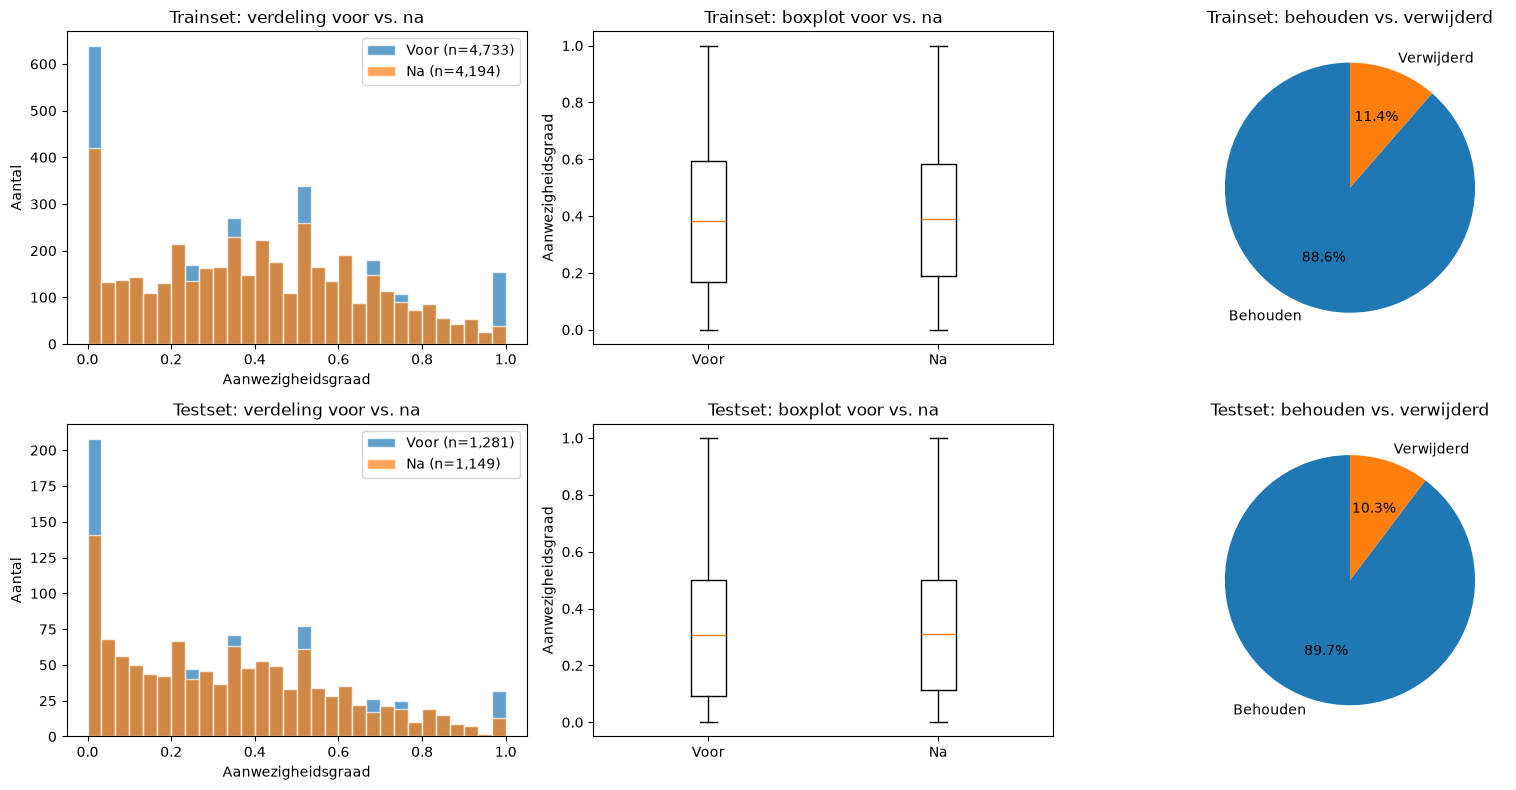

TRAINSET
Voor cleaning: 4,733 rijen
Na cleaning:   4,194 rijen
Verwijderd:    539 rijen (11.4%)
Mediaan voor:  38.2%
Mediaan na:    38.9%
Gemiddelde voor: 39.4%
Gemiddelde na:   39.4%

TESTSET
Voor cleaning: 1,281 rijen
Na cleaning:   1,149 rijen
Verwijderd:    132 rijen (10.3%)
Mediaan voor:  30.8%
Mediaan na:    31.0%
Gemiddelde voor: 33.3%
Gemiddelde na:   33.5%


In [59]:
# Vergelijking train- en testset voor vs. na cleaning

fig, axes = plt.subplots(2, 3, figsize=(16, 8))


# ============================================================
# TRAINSET
# ============================================================

# 1. Verdeling voor en na cleaning

axes[0, 0].hist(
    train_df_voor_cleaning["aanwezigheidsgraad"],
    bins=30,
    alpha=0.7,
    edgecolor="white",
    label=f"Voor (n={len(train_df_voor_cleaning):,})"
)

axes[0, 0].hist(
    train_df["aanwezigheidsgraad"],
    bins=30,
    alpha=0.7,
    edgecolor="white",
    label=f"Na (n={len(train_df):,})"
)

axes[0, 0].set_title("Trainset: verdeling voor vs. na")
axes[0, 0].set_xlabel("Aanwezigheidsgraad")
axes[0, 0].set_ylabel("Aantal")
axes[0, 0].legend()


# 2. Boxplot

axes[0, 1].boxplot(
    [
        train_df_voor_cleaning["aanwezigheidsgraad"].dropna(),
        train_df["aanwezigheidsgraad"].dropna()
    ],
    tick_labels=["Voor", "Na"]
)

axes[0, 1].set_title("Trainset: boxplot voor vs. na")
axes[0, 1].set_ylabel("Aanwezigheidsgraad")


# 3. Behouden vs verwijderd

train_voor = len(train_df_voor_cleaning)
train_na = len(train_df)
train_verwijderd = train_voor - train_na

axes[0, 2].pie(
    [train_na, train_verwijderd],
    labels=["Behouden", "Verwijderd"],
    autopct="%1.1f%%",
    startangle=90
)

axes[0, 2].set_title("Trainset: behouden vs. verwijderd")


# ============================================================
# TESTSET
# ============================================================

# 4. Verdeling voor en na cleaning

axes[1, 0].hist(
    test_df_voor_cleaning["aanwezigheidsgraad"],
    bins=30,
    alpha=0.7,
    edgecolor="white",
    label=f"Voor (n={len(test_df_voor_cleaning):,})"
)

axes[1, 0].hist(
    test_df["aanwezigheidsgraad"],
    bins=30,
    alpha=0.7,
    edgecolor="white",
    label=f"Na (n={len(test_df):,})"
)

axes[1, 0].set_title("Testset: verdeling voor vs. na")
axes[1, 0].set_xlabel("Aanwezigheidsgraad")
axes[1, 0].set_ylabel("Aantal")
axes[1, 0].legend()


# 5. Boxplot

axes[1, 1].boxplot(
    [
        test_df_voor_cleaning["aanwezigheidsgraad"].dropna(),
        test_df["aanwezigheidsgraad"].dropna()
    ],
    tick_labels=["Voor", "Na"]
)

axes[1, 1].set_title("Testset: boxplot voor vs. na")
axes[1, 1].set_ylabel("Aanwezigheidsgraad")


# 6. Behouden vs verwijderd

test_voor = len(test_df_voor_cleaning)
test_na = len(test_df)
test_verwijderd = test_voor - test_na

axes[1, 2].pie(
    [test_na, test_verwijderd],
    labels=["Behouden", "Verwijderd"],
    autopct="%1.1f%%",
    startangle=90
)

axes[1, 2].set_title("Testset: behouden vs. verwijderd")


plt.tight_layout()
plt.show()


# ============================================================
# Overzicht in cijfers
# ============================================================

print("TRAINSET")
print(f"Voor cleaning: {train_voor:,} rijen")
print(f"Na cleaning:   {train_na:,} rijen")
print(
    f"Verwijderd:    {train_verwijderd:,} rijen "
    f"({train_verwijderd / train_voor * 100:.1f}%)"
)

print(
    f"Mediaan voor:  "
    f"{train_df_voor_cleaning['aanwezigheidsgraad'].median():.1%}"
)
print(
    f"Mediaan na:    "
    f"{train_df['aanwezigheidsgraad'].median():.1%}"
)

print(
    f"Gemiddelde voor: "
    f"{train_df_voor_cleaning['aanwezigheidsgraad'].mean():.1%}"
)
print(
    f"Gemiddelde na:   "
    f"{train_df['aanwezigheidsgraad'].mean():.1%}"
)


print("\nTESTSET")
print(f"Voor cleaning: {test_voor:,} rijen")
print(f"Na cleaning:   {test_na:,} rijen")
print(
    f"Verwijderd:    {test_verwijderd:,} rijen "
    f"({test_verwijderd / test_voor * 100:.1f}%)"
)

print(
    f"Mediaan voor:  "
    f"{test_df_voor_cleaning['aanwezigheidsgraad'].median():.1%}"
)
print(
    f"Mediaan na:    "
    f"{test_df['aanwezigheidsgraad'].median():.1%}"
)

print(
    f"Gemiddelde voor: "
    f"{test_df_voor_cleaning['aanwezigheidsgraad'].mean():.1%}"
)
print(
    f"Gemiddelde na:   "
    f"{test_df['aanwezigheidsgraad'].mean():.1%}"
)

# Fase 5  — Feature Engineering

**5.1 Huidige features inventariseren**

In [60]:
# Volledig overzicht van alle beschikbare kolommen

feature_overzicht = pd.DataFrame({
    "Datatype": train_df.dtypes.astype(str),
    "UniekeWaarden": train_df.nunique(),
    "Voorbeeld": [
        train_df[col].dropna().iloc[0]
        if train_df[col].notna().any()
        else None
        for col in train_df.columns
    ]
})

print(feature_overzicht.to_string())

                             Datatype  UniekeWaarden                                  Voorbeeld
LectureID                       int64           2406                                     474170
DateKey                         int64             52                                   20251118
FromTimeKey                     int64             29                                      81500
UntilTimeKey                    int64             36                                      91500
ClassKey                        int64            336                                       3907
SubgroupKey                     int64            960                                    5801099
RoomKey                         int64             72                                       1111
ActivityKey                     int64             11                                         18
UserCount                     float64             56                                        8.0
TotalStudents                   int64   

**5.2 Aanmaken nieuwe features**

**5.2.1 Bezettingsgraad v/h lokaal**

In [61]:
train_df["LokaalBezettingsgraad"] = (
    train_df["TotalStudents"] / train_df["Capacity"]
)

test_df["LokaalBezettingsgraad"] = (
    test_df["TotalStudents"] / test_df["Capacity"]
)


print("Correlatie met aanwezigheidsgraad:")
print(
    train_df[
        ["LokaalBezettingsgraad", "aanwezigheidsgraad"]
    ].corr()
)

Correlatie met aanwezigheidsgraad:
                       LokaalBezettingsgraad  aanwezigheidsgraad
LokaalBezettingsgraad               1.000000           -0.038649
aanwezigheidsgraad                 -0.038649            1.000000


LokaalBezettingsgraad verwijderen we niet enkel wegens die -0,039, maar vooral omdat de feature inhoudelijk mogelijk misleidend is: TotalStudents / Capacity klopt niet altijd als één les over meerdere subgroepen/lokalen verdeeld is. Deze feature wordt in het volgende deel niet meegenomen.

**5.2.2 Tijdstip van de dag**

In [62]:
def maak_dagdeel(uur):
    if uur < 12:
        return "Ochtend"
    elif uur < 17:
        return "Namiddag"
    else:
        return "Avond"

train_df["Dagdeel"] = train_df["StartHour"].apply(maak_dagdeel)
test_df["Dagdeel"] = test_df["StartHour"].apply(maak_dagdeel)

# Gemiddelde aanwezigheid per dagdeel

print("Gemiddelde aanwezigheid per dagdeel:")
print(
    train_df.groupby("Dagdeel")["aanwezigheidsgraad"]
    .agg(["count", "mean"])
    .round(3)
)


# Dagdeel tijdelijk numeriek maken voor correlatie
dagdeel_mapping = {
    "Ochtend": 0,
    "Namiddag": 1,
    "Avond": 2
}

dagdeel_num = train_df["Dagdeel"].map(dagdeel_mapping)

correlatie_dagdeel = dagdeel_num.corr(
    train_df["aanwezigheidsgraad"]
)

print(
    f"Correlatie Dagdeel met aanwezigheidsgraad: "
    f"{correlatie_dagdeel:.3f}"
)

Gemiddelde aanwezigheid per dagdeel:
          count   mean
Dagdeel               
Avond       203  0.400
Namiddag   1573  0.403
Ochtend    2418  0.387
Correlatie Dagdeel met aanwezigheidsgraad: 0.027


**5.3.3 Weekdag / Weekend**

In [63]:
# Weekendfeature maken
# Weekday 7 = zaterdag
# Weekday 1 = zondag (komt momenteel niet voor in trainset)

train_df["IsWeekend"] = train_df["Weekday"].isin([1, 7]).astype(int)
test_df["IsWeekend"] = test_df["Weekday"].isin([1, 7]).astype(int)

print("TRAINSET:")
print(train_df["IsWeekend"].value_counts())

print("\nTESTSET:")
print(test_df["IsWeekend"].value_counts())

# Correlatie IsWeekend met aanwezigheidsgraad

correlatie_weekend = train_df["IsWeekend"].corr(
    train_df["aanwezigheidsgraad"]
)

print(
    f"Correlatie IsWeekend met aanwezigheidsgraad: "
    f"{correlatie_weekend:.3f}"
)

TRAINSET:
IsWeekend
0    4155
1      39
Name: count, dtype: int64

TESTSET:
IsWeekend
0    1140
1       9
Name: count, dtype: int64
Correlatie IsWeekend met aanwezigheidsgraad: -0.003


In [64]:
# IsWeekend verwijderen omdat we besloten hebben deze feature niet te behouden

train_df.drop(columns=["IsWeekend"], inplace=True)
test_df.drop(columns=["IsWeekend"], inplace=True)

print("IsWeekend verwijderd.")

IsWeekend verwijderd.


**5.3.3.1 Conclusie Weekdag/Weekend**

Een aparte weekendfeature werd overwogen, maar niet behouden. Slechts 39 rijen (0,9%) in de trainset en 9 rijen (0,8%) in de testset vallen in het weekend, uitsluitend op zaterdag. Bovendien is deze informatie al aanwezig in Weekday. Een aparte IsWeekend-feature zou daarom weinig extra informatie toevoegen.

**5.4.4 Regen of geen regen**

In [65]:
train_df["HeeftGeregend"] = (train_df["TotaleRegen"] > 0).astype(int)
test_df["HeeftGeregend"] = (test_df["TotaleRegen"] > 0).astype(int)

**5.4.5 Conclusie**

Tijdens feature engineering werden nieuwe kenmerken afgeleid uit de bestaande data. SemesterWeek, Lesduur, Groepsgrootte, Dagdeel en HeeftGeregend werden behouden omdat ze relevante informatie op een beter interpreteerbare manier kunnen voorstellen. Daarnaast werden IsWeekend en LokaalBezettingsgraad onderzocht. IsWeekend werd niet behouden omdat weekendlessen zeer weinig voorkomen en de informatie reeds aanwezig is in Weekday. LokaalBezettingsgraad werd niet behouden omdat uit verdere analyse bleek dat één lesmoment aan meerdere subgroepen en lokalen gekoppeld kan zijn, waardoor de verhouding tussen TotalStudents en de capaciteit van één lokaal misleidend kan zijn.

**5.5 Selectie van features voor het model**

Onze target is: aanwezigheidsgraad = UserCount / TotalStudents

In [66]:
target = "aanwezigheidsgraad"

drop_features = [
    # Target leakage
    "UserCount",

    # Technische identifiers
    "LectureID",
    "DateKey",
    "FromTimeKey",
    "UntilTimeKey",
    "ClassKey",
    "SubgroupKey",
    "RoomKey",
    "ActivityKey",

    # Onderzocht maar niet behouden
    "LokaalBezettingsgraad"
]

print("Target:", target)
print("Niet gebruiken als modelinput:")
print(drop_features)

Target: aanwezigheidsgraad
Niet gebruiken als modelinput:
['UserCount', 'LectureID', 'DateKey', 'FromTimeKey', 'UntilTimeKey', 'ClassKey', 'SubgroupKey', 'RoomKey', 'ActivityKey', 'LokaalBezettingsgraad']


**5.5.1 Conclusie**

Aanwezigheidsgraad is de doelvariabele. UserCount wordt niet als feature gebruikt omdat de aanwezigheidsgraad rechtstreeks uit UserCount / TotalStudents wordt berekend en dit dus target leakage zou veroorzaken. Technische identifiers worden eveneens niet als modelinput gebruikt, omdat hun numerieke waarde op zichzelf geen inhoudelijke betekenis heeft.

# Fase 6 - Data voorbereiden voor Machine Learning

**6.1 Features & Target scheiden**

In [67]:
# Target
target = "aanwezigheidsgraad"

# Kolommen die niet als input gebruikt worden
drop_features = [
    # Target leakage
    "UserCount",

    # Technische identifiers
    "LectureID",
    "DateKey",
    "FromTimeKey",
    "UntilTimeKey",
    "ClassKey",
    "SubgroupKey",
    "RoomKey",
    "ActivityKey",
    "LokaalBezettingsgraad",
    
     # Hoge cardinaliteit / te specifieke identificatie
    "SubgroupCode",
    "ClassName",
    "RoomCode",
    "RoomName"

]

# Features en target splitsen
X_train = train_df.drop(
    columns=[target] + drop_features
).copy()

y_train = train_df[target].copy()

X_test = test_df.drop(
    columns=[target] + drop_features
).copy()

y_test = test_df[target].copy()


# Controle
print("TRAINSET")
print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")

print("\nTESTSET")
print(f"X_test:  {X_test.shape}")
print(f"y_test:  {y_test.shape}")

print("\nControle:")
print(f"Aanwezigheidsgraad in X_train: {target in X_train.columns}")
print(f"UserCount in X_train:          {'UserCount' in X_train.columns}")

TRAINSET
X_train: (4194, 59)
y_train: (4194,)

TESTSET
X_test:  (1149, 59)
y_test:  (1149,)

Controle:
Aanwezigheidsgraad in X_train: False
UserCount in X_train:          False


**6.2 Preprocessing**

**6.2.1 Numerieke en categorische features bepalen**

In [68]:
# Numerieke en categorische features bepalen

numerieke_features = X_train.select_dtypes(
    include="number"
).columns.tolist()

categorische_features = X_train.select_dtypes(
    include=["object", "str", "category"]
).columns.tolist()

datum_features = X_train.select_dtypes(
    include=["datetime"]
).columns.tolist()

print(f"Aantal numerieke features: {len(numerieke_features)}")
print(f"Aantal categorische features: {len(categorische_features)}")
print(f"Aantal datumfeatures: {len(datum_features)}")

print("\nDatumfeatures:")
print(datum_features)

Aantal numerieke features: 42
Aantal categorische features: 16
Aantal datumfeatures: 1

Datumfeatures:
['FullDate']


**6.2.2 Datumfeature verwijderen**


In [69]:
# FullDate verwijderen uit de modelinput

X_train = X_train.drop(columns=["FullDate"])
X_test = X_test.drop(columns=["FullDate"])

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (4194, 58)
X_test: (1149, 58)


**6.2.3 Features opnieuw indelen**

In [70]:
# Numerieke en categorische features opnieuw bepalen

numerieke_features = X_train.select_dtypes(
    include="number"
).columns.tolist()

categorische_features = X_train.select_dtypes(
    include=["object", "str", "category"]
).columns.tolist()

print(f"Aantal numerieke features: {len(numerieke_features)}")
print(f"Aantal categorische features: {len(categorische_features)}")

print("\nNumerieke features:")
print(numerieke_features)

print("\nCategorische features:")
print(categorische_features)

Aantal numerieke features: 42
Aantal categorische features: 16

Numerieke features:
['TotalStudents', 'Weekday', 'Month', 'Year', 'DayOfYear', 'NumberSemester', 'StartHour', 'StartMinutes', 'StartSeconds', 'EndHour', 'EndMinutes', 'EndSeconds', 'IsCourse', 'IsExam', 'IsAcademicEvent', 'IsGuestLecture', 'IsMakeUp', 'IsPractical', 'IsPresentation', 'IsDigitalPossible', 'ClassCode', 'ClassCredits', 'ClassSecondChance', 'ClassProgramStage', 'Building', 'RoomFloor', 'Capacity', 'Area', 'Stakingsdag', 'GemiddeldeTemperatuur', 'MaximumTemperatuur', 'MinimumTemperatuur', 'TotaleNeerslag', 'TotaleRegen', 'MaximaleWindsnelheid', 'WeerCode', 'ZonneschijnSeconden', 'DaglichtSeconden', 'NeerslagUren', 'SemesterWeek', 'Lesduur', 'HeeftGeregend']

Categorische features:
['NameDayDutch', 'NameMonthDutch', 'Season', 'StartTime', 'StartAMPM', 'EndTime', 'EndAMPM', 'CanonicalActivity', 'ActivityDomain', 'ActivityGroup', 'SourceColumn', 'SourceValue', 'ProgramName', 'RoomCategory', 'Groepsgrootte', 'Dagde

**6.2.4 Preprocessing-pipeline opbouwen**

De numerieke en categorische kenmerken vereisen een verschillende preprocessing. Numerieke kenmerken worden geïmputeerd en geschaald. Categorische kenmerken worden geïmputeerd en via One-Hot Encoding omgezet naar numerieke waarden.

In [71]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# Pipeline voor numerieke features
numerieke_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Pipeline voor categorische features
categorische_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Beide pipelines combineren
preprocessor = ColumnTransformer([
    ("num", numerieke_pipeline, numerieke_features),
    ("cat", categorische_pipeline, categorische_features)
])

print("Preprocessor aangemaakt.")

Preprocessor aangemaakt.


**6.2.5 Preprocessing fitten en controleren**

In [72]:
# Preprocessing fitten op de trainset

X_train_processed = preprocessor.fit_transform(X_train)

# Dezelfde preprocessing toepassen op de testset
X_test_processed = preprocessor.transform(X_test)

print("X_train_processed:", X_train_processed.shape)
print("X_test_processed:", X_test_processed.shape)

X_train_processed: (4194, 234)
X_test_processed: (1149, 234)


In [73]:
# Namen van de uiteindelijke features ophalen

feature_namen = preprocessor.get_feature_names_out()

print(f"Aantal features vóór preprocessing: {X_train.shape[1]}")
print(f"Aantal features na preprocessing:   {len(feature_namen)}")

print("\nEerste 20 features:")
print(feature_namen[:20])

Aantal features vóór preprocessing: 58
Aantal features na preprocessing:   234

Eerste 20 features:
['num__TotalStudents' 'num__Weekday' 'num__Month' 'num__Year'
 'num__DayOfYear' 'num__NumberSemester' 'num__StartHour'
 'num__StartMinutes' 'num__StartSeconds' 'num__EndHour' 'num__EndMinutes'
 'num__EndSeconds' 'num__IsCourse' 'num__IsExam' 'num__IsAcademicEvent'
 'num__IsGuestLecture' 'num__IsMakeUp' 'num__IsPractical'
 'num__IsPresentation' 'num__IsDigitalPossible']


In [74]:
# Aantal categorieën per categorische feature

categorie_overzicht = (
    X_train[categorische_features]
    .nunique()
    .sort_values(ascending=False)
)

print(categorie_overzicht)

ProgramName          64
EndTime              36
StartTime            29
CanonicalActivity    11
SourceValue          11
ActivityGroup         9
RoomCategory          6
NameDayDutch          6
Groepsgrootte         5
Dagdeel               3
NameMonthDutch        3
StartAMPM             2
SourceColumn          2
EndAMPM               2
ActivityDomain        2
Season                1
dtype: int64


**6.2.5.1** Conclusie

Na het verwijderen van sterk identificerende categorische kenmerken bevat de dataset 58 inputfeatures. Door One-Hot Encoding van de resterende categorische variabelen stijgt dit aantal naar 234. 

Ik fit de preprocessing alleen op de trainset en pas daarna exact dezelfde transformaties toe op de testset. Zo vermijd ik data leakage. Door one-hot encoding stijgt het aantal features, omdat één categorische kolom wordt opgesplitst in meerdere binaire kolommen.

# Fase 7 - Modellen trainen / vergelijken

In [75]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import cross_val_score, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor

**7.1 Eerste modelvergelijking**

In [76]:
# Time Series Cross Validation

tscv = TimeSeriesSplit(n_splits=5)


# Modellen

modellen = {
    "Baseline (gemiddelde)": DummyRegressor(strategy="mean"),

    "Linear Regression": LinearRegression(),

    "Decision Tree": DecisionTreeRegressor(
        max_depth=8,
        random_state=42
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        n_jobs=-1,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=100,
        random_state=42
    ),

    "XGBoost": XGBRegressor(
        n_estimators=300,
        learning_rate = 0.05,
        max_depth = 6,
        random_state = 42,
        n_jobs=-1
    )
}

In [77]:
# Resultaten opslaan

resultaten = {}

for naam, model in modellen.items():

    pipe = Pipeline([
        ("preprocessing", preprocessor),
        ("model", model)
    ])

    scores = -cross_val_score(
        pipe,
        X_train,
        y_train,
        scoring="neg_mean_absolute_error",
        cv=tscv,
        n_jobs=-1
    )

    resultaten[naam] = {
        "MAE": scores.mean(),
        "Std": scores.std()
    }


# Resultaten omzetten naar DataFrame en sorteren

resultaten_df = pd.DataFrame(resultaten).T

resultaten_df = resultaten_df.sort_values(
    by="MAE",
    ascending=True
)

print("Modelvergelijking (beste → slechtste):")
display(resultaten_df.round(4))

Modelvergelijking (beste → slechtste):


,MAE,Std
Random Forest,0.1815,0.0112
XGBoost,0.1870,0.0130
Gradient Boosting,0.1885,0.0117
Decision Tree,0.2046,0.0159
Baseline (gemiddelde),0.2191,0.0131
Linear Regression,0.2994,0.0937


**7.2 Twee beste modellen vergelijken en best presterende kiezen**


Op basis van de cross-validatie worden zowel Random Forest als XGBoost geselecteerd. Beiden halen een MAE resp. van 0.1815 en 0.1870 en presteren net iets beter als de andere modellen. 

In de volgende stap worden de hyperparameters van het Random Forest-model & XGBoost geoptimaliseerd. De testset wordt hierbij nog niet gebruikt. Vanuit de fine tuning zullen we een definitieve beslissing nemen welk model we gaan kiezen.



**7.3 Hyperparameter tuning XGBoost.**

In [78]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor

# XGBoost pipeline ORIGNEEL
xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(
        random_state=42,
        n_jobs=-1
    ))
])

# Hyperparameters die we willen testen
xgb_params = {
    "model__n_estimators": [100, 200, 300, 500],  #hoeveel bomen
    "model__max_depth": [3, 4, 5, 6, 8], #hoe diep elke boom mag worden
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1], #hoe sterk elke nieuwe boom het model corrigeert
    "model__subsample": [0.7, 0.8, 0.9, 1.0], #welk percentage van de trainingsrijen elke boom gebruikt
    "model__colsample_bytree": [0.6, 0.8, 1.0] # welk percentage van de features elke boom gebruikt
}

# Randomized Search
xgb_search = RandomizedSearchCV( #test het aantal combinaties uit in plaats van alle combinaties hierboven
    estimator=xgb_pipeline,
    param_distributions=xgb_params,
    n_iter=30,
    scoring="neg_mean_absolute_error",
    cv=tscv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Trainen
xgb_search.fit(X_train, y_train)

# Resultaten
print("Beste parameters:")
print(xgb_search.best_params_)

print()
print(f"Beste XGBoost CV MAE: {-xgb_search.best_score_:.4f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Beste parameters:
{'model__subsample': 1.0, 'model__n_estimators': 200, 'model__max_depth': 8, 'model__learning_rate': 0.05, 'model__colsample_bytree': 0.6}

Beste XGBoost CV MAE: 0.1818


**7.3.1 Hyperparameter tuning XGBoost met bredere parameters (als extra test).**

In [ ]:
from scipy.stats import randint, uniform, loguniform
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor

xgb_pipeline = Pipeline([  #bredere parameters tuning XGBoost
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(
        random_state=42,
        n_jobs=-1,
        objective="reg:squarederror"
    ))
])

xgb_param_distributions = {   # in plaats van vaste waarden gebruiken we kansverdelingen van scipy.stats
    # Aantal boosting-rondes / bomen
    "model__n_estimators": randint(100, 1001),

    # Diepte van elke boom
    "model__max_depth": randint(2, 11),

    # Learning rate: log-schaal is hier nuttig
    "model__learning_rate": loguniform(0.005, 0.2),

    # Deel van de trainingsobservaties per boom
    "model__subsample": uniform(0.6, 0.4),

    # Deel van de features per boom
    "model__colsample_bytree": uniform(0.5, 0.5),

    # Minimum gewicht nodig om verder te splitsen
    "model__min_child_weight": randint(1, 11),

    # Regularisatie
    "model__reg_alpha": loguniform(1e-4, 1),
    "model__reg_lambda": loguniform(0.1, 10)
}

xgb_search_breed = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=xgb_param_distributions,
    n_iter=50,
    scoring="neg_mean_absolute_error",
    cv=tscv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

xgb_search_breed.fit(X_train, y_train)

print("Beste parameters:")
print(xgb_search_breed.best_params_)

print()
print(f"Beste XGBoost CV MAE: {-xgb_search_breed.best_score_:.4f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Beste parameters:
{'model__colsample_bytree': np.float64(0.8861223846483287), 'model__learning_rate': np.float64(0.01040697346842839), 'model__max_depth': 9, 'model__min_child_weight': 3, 'model__n_estimators': 692, 'model__reg_alpha': np.float64(0.0700434954523006), 'model__reg_lambda': np.float64(3.804968634158325), 'model__subsample': np.float64(0.8423839899124046)}

Beste XGBoost CV MAE: 0.1808


**7.4 Hyperparameter tuning Random Forest.**

In [80]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

# Pipeline met preprocessing + Random Forest ORIGINEEL
rf_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ))
])

# Mogelijke waarden voor de hyperparameters
param_distributions = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [None, 8, 12, 16, 20],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", 0.5, 1.0]
}

# Randomized Search
random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_distributions,
    n_iter=30,
    scoring="neg_mean_absolute_error",
    cv=tscv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Fit enkel op de trainset
random_search.fit(X_train, y_train)

print("Beste parameters:")
print(random_search.best_params_)

print("\nBeste CV MAE:")
print(f"{-random_search.best_score_:.4f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Beste parameters:
{'model__n_estimators': 300, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': 1.0, 'model__max_depth': 20}

Beste CV MAE:
0.1816


**7.4.1 Hyperparameter tuning Random Forest met bredere parameters (als extra test).**

In [81]:
from scipy.stats import randint, uniform
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ))
])

param_distributions = {
    # Aantal bomen
    "model__n_estimators": randint(100, 1001),

    # Maximale diepte van een boom
    "model__max_depth": randint(5, 41),

    # Minimum aantal observaties om een node te splitsen
    "model__min_samples_split": randint(2, 21),

    # Minimum aantal observaties in een leaf
    "model__min_samples_leaf": randint(1, 11),

    # Deel van de features dat per split bekeken wordt
    "model__max_features": uniform(0.3, 0.7)
}

rf_search_breed = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_distributions,
    n_iter=50,
    scoring="neg_mean_absolute_error",
    cv=tscv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_search_breed.fit(X_train, y_train)

print("Beste parameters:")
print(rf_search_breed.best_params_)

print()
print(f"Beste Random Forest CV MAE: {-rf_search_breed.best_score_:.4f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Beste parameters:
{'model__max_depth': 26, 'model__max_features': np.float64(0.9210489198034286), 'model__min_samples_leaf': 1, 'model__min_samples_split': 4, 'model__n_estimators': 712}

Beste Random Forest CV MAE: 0.1813


**7.4.2 Conclusie hyperparameter tuning**

Voor zowel Random Forest als XGBoost werd naast een eerste hyperparameteroptimalisatie ook een bredere RandomizedSearchCV uitgevoerd. Bij de bredere optimalisatie werden de hyperparameters niet enkel uit een beperkt aantal vaste waarden gekozen, maar werden bredere kansverdelingen gebruikt. Hierdoor kon een groter deel van de mogelijke hyperparametercombinaties worden onderzocht.

Bij Random Forest behaalde de eerste tuning een gemiddelde cross-validation MAE van 0.1816. De bredere zoekruimte verbeterde dit resultaat licht tot 0.1813.
Bij XGBoost behaalde de eerste tuning een gemiddelde cross-validation MAE van 0.1818. De bredere hyperparameteroptimalisatie verbeterde dit resultaat tot 0.1808. Dit is de laagste cross-validation MAE van de geteste configuraties.

De verschillen tussen de beste modellen zijn klein. Een bredere zoekruimte leidt dus niet automatisch tot een grote verbetering, maar maakt het wel mogelijk om meer mogelijke hyperparametercombinaties te onderzoeken. Op basis van de cross-validation presteert de breed geoptimaliseerde XGBoost voorlopig het beste. De uiteindelijke modelkeuze wordt daarna nog gecontroleerd op de aparte testset.

**7.5 Evaluatie op de testset**

Het definitieve Random Forest-model wordt nu geëvalueerd op de testset.
Deze testset werd niet gebruikt tijdens de modelselectie of hyperparameter tuning.

Voor de evaluatie worden MAE, RMSE en R² gebruikt.

In [82]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# ============================================================
# RANDOM FOREST - BREDE TUNING
# ============================================================

best_rf_model = rf_search_breed.best_estimator_

y_pred_rf = best_rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)


# ============================================================
# XGBOOST - BREDE TUNING
# ============================================================

best_xgb_model = xgb_search_breed.best_estimator_

y_pred_xgb = best_xgb_model.predict(X_test)

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)


# ============================================================
# VERGELIJKING
# ============================================================

print(f"{'Metriek':<10} {'Random Forest':>15} {'XGBoost':>15}")
print("-" * 42)

print(f"{'MAE':<10} {mae_rf:>15.4f} {mae_xgb:>15.4f}")
print(f"{'RMSE':<10} {rmse_rf:>15.4f} {rmse_xgb:>15.4f}")
print(f"{'R²':<10} {r2_rf:>15.4f} {r2_xgb:>15.4f}")

print()
print(f"Random Forest MAE: {mae_rf * 100:.2f} procentpunten")
print(f"XGBoost MAE:       {mae_xgb * 100:.2f} procentpunten")

if mae_xgb < mae_rf:
    print("\nBeste model op de testset: XGBoost")
else:
    print("\nBeste model op de testset: Random Forest")

Metriek      Random Forest         XGBoost
------------------------------------------
MAE                 0.1570          0.1582
RMSE                0.2072          0.2082
R²                  0.3166          0.3097

Random Forest MAE: 15.70 procentpunten
XGBoost MAE:       15.82 procentpunten

Beste model op de testset: Random Forest


**7.5.1 Conclusie na testset**

Na brede hyperparameteroptimalisatie behaalde XGBoost tijdens de time-series cross-validation een iets lagere MAE (0.1808) dan Random Forest (0.1813). Het verschil tussen beide modellen was echter zeer klein.

Op de afzonderlijk gehouden testset presteerde Random Forest uiteindelijk iets beter. Random Forest behaalde een MAE van 0.1570, een RMSE van 0.2072 en een R² van 0.3166. XGBoost behaalde respectievelijk een MAE van 0.1589, een RMSE van 0.2089 en een R² van 0.3053.

Omdat Random Forest op de onafhankelijke testset op alle drie de evaluatiemetrieken iets beter presteert, wordt Random Forest behouden als definitief model.

**7.6 Definitief model**

Na de hyperparameter tuning wordt het beste Random Forest-model gebruikt
als finaal model. Het model wordt vervolgens geëvalueerd op de afzonderlijk
gehouden testset.

In [83]:
best_model = rf_search_breed.best_estimator_

print("Definitief model:")
print(best_model.named_steps["model"])

Definitief model:
RandomForestRegressor(max_depth=26, max_features=np.float64(0.9210489198034286),
                      min_samples_split=4, n_estimators=712, n_jobs=-1,
                      random_state=42)


In [84]:
# ============================================================
# Definitief Random Forest evalueren
# ============================================================

y_pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)


# ============================================================
# Baseline evalueren
# ============================================================

baseline = DummyRegressor(strategy="mean")
baseline.fit(X_train, y_train)

y_pred_baseline = baseline.predict(X_test)

mae_baseline = mean_absolute_error(y_test, y_pred_baseline)
rmse_baseline = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
r2_baseline = r2_score(y_test, y_pred_baseline)


# ============================================================
# Vergelijking
# ============================================================

print(f"{'Metriek':<10} {'Baseline':>12} {'Random Forest':>15}")
print("-" * 40)
print(f"{'MAE':<10} {mae_baseline:>12.4f} {mae:>15.4f}")
print(f"{'RMSE':<10} {rmse_baseline:>12.4f} {rmse:>15.4f}")
print(f"{'R²':<10} {r2_baseline:>12.4f} {r2:>15.4f}")

Metriek        Baseline   Random Forest
----------------------------------------
MAE              0.2173          0.1570
RMSE             0.2575          0.2072
R²              -0.0556          0.3166


**7.7 Visualisatie van de voorspellingen**

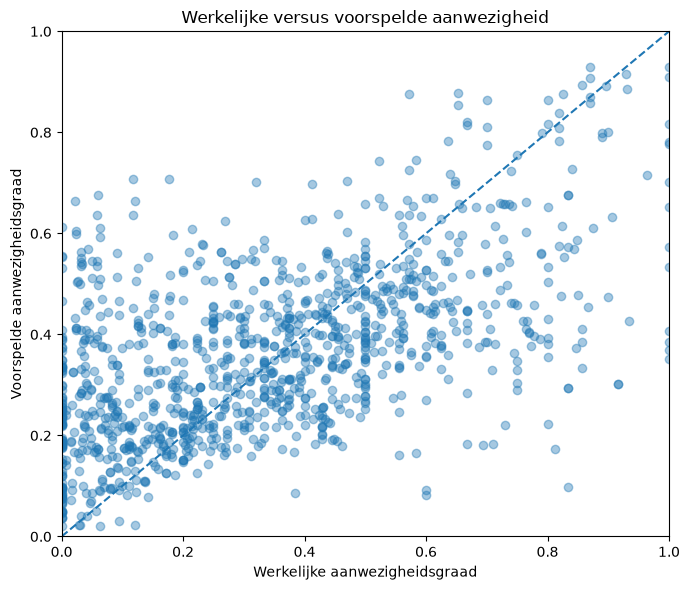

In [85]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.4
)

# Perfecte voorspelling
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("Werkelijke aanwezigheidsgraad")
plt.ylabel("Voorspelde aanwezigheidsgraad")
plt.title("Werkelijke versus voorspelde aanwezigheid")

plt.xlim(0, 1)
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

**7.7.1 Conclusie Visualisatie**

De voorspellingen vertonen een duidelijke positieve relatie met de werkelijke
aanwezigheidsgraad. De punten liggen echter niet volledig op de diagonale lijn,
wat aangeeft dat er nog aanzienlijke voorspellingsfouten voorkomen.

Bij zeer lage aanwezigheid heeft het model de neiging om de aanwezigheid te
overschatten, terwijl hoge aanwezigheidsgraden regelmatig worden onderschat.
De voorspellingen worden dus gedeeltelijk naar gemiddelde waarden getrokken.

Dit sluit aan bij de R²-score van 0.3166: het model kan een deel van de variatie
in aanwezigheid verklaren, maar niet alle verschillen tussen lessen.

**7.8 Residuen**

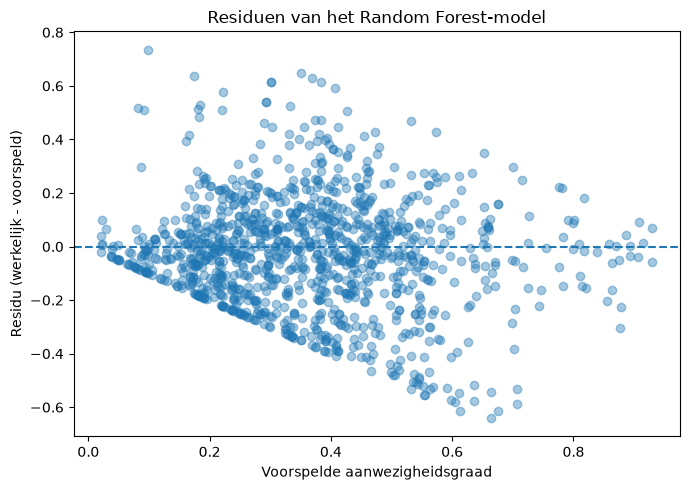

Gemiddeld residu: -0.0261


In [86]:
# Residuen berekenen
residuen = y_test - y_pred

plt.figure(figsize=(7, 5))

plt.scatter(
    y_pred,
    residuen,
    alpha=0.4
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Voorspelde aanwezigheidsgraad")
plt.ylabel("Residu (werkelijk - voorspeld)")
plt.title("Residuen van het Random Forest-model")

plt.tight_layout()
plt.show()

print(f"Gemiddeld residu: {residuen.mean():.4f}")

**7.8.1 Conclusie Residuen**

De residuen liggen zowel boven als onder nul, maar vertonen een aanzienlijke
spreiding. Het gemiddelde residu bedraagt -0.0261. Dit betekent dat het model
de aanwezigheidsgraad gemiddeld met ongeveer 2,61 procentpunt overschat.

De residuen tonen daarnaast dat de voorspellingsfout voor individuele lessen
nog relatief groot kan zijn. Dit sluit aan bij de MAE van 0.1570 en de
R²-score van 0.3166: het Random Forest voorspelt duidelijk beter dan de
baseline, maar kan niet alle variatie in de aanwezigheid verklaren.

**7.9 Feature Importance**


Om het Random Forest-model beter te interpreteren, bekijken we welke features
het belangrijkst zijn voor het maken van voorspellingen.

                        Feature  Importance
                 num__ClassCode    0.125531
             num__TotalStudents    0.106048
              num__ClassCredits    0.081200
                      num__Area    0.054218
                  num__Capacity    0.052729
 cat__RoomCategory_laboratorium    0.031653
      num__MaximaleWindsnelheid    0.031405
       num__ZonneschijnSeconden    0.027546
          num__DaglichtSeconden    0.025953
                 num__DayOfYear    0.022841
                   num__Lesduur    0.022056
        num__MaximumTemperatuur    0.021522
     cat__ProgramName_GRAD-LABT    0.020635
        num__MinimumTemperatuur    0.020517
         num__ClassProgramStage    0.019801
                 num__RoomFloor    0.018826
     num__GemiddeldeTemperatuur    0.018307
cat__ProgramName_GRAD-SYS1-GENT    0.015486
                   num__Weekday    0.010441
              num__NeerslagUren    0.010397


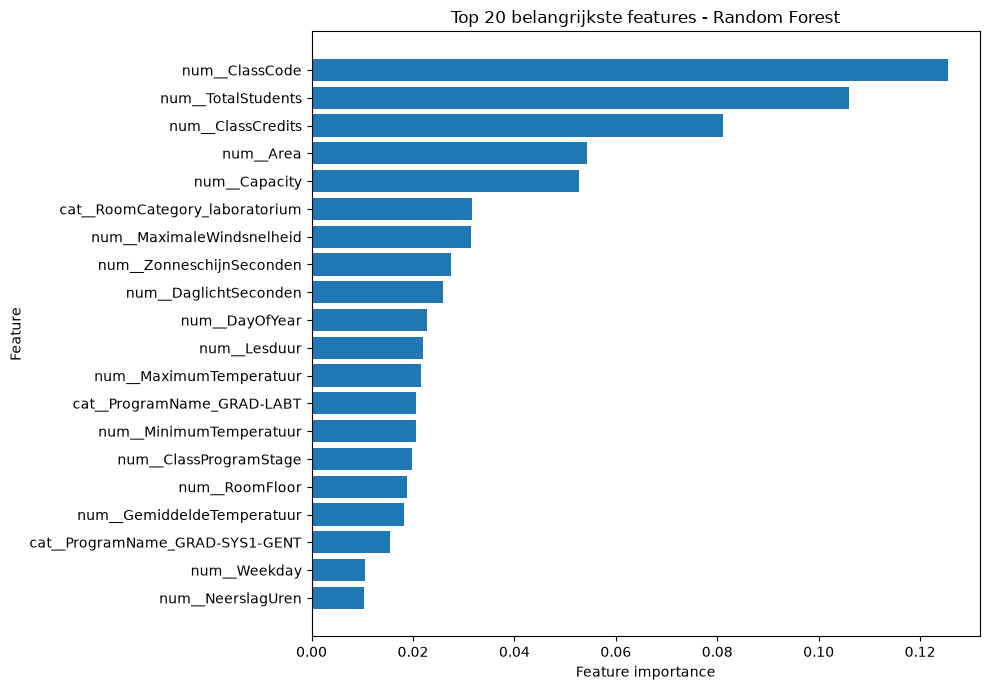

In [87]:
# Namen van de features na preprocessing
feature_names = preprocessor.get_feature_names_out()

# Feature importances van het getrainde Random Forest-model
importances = best_model.named_steps["model"].feature_importances_

# DataFrame maken
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

# Top 20 tonen
print(feature_importance.head(20).to_string(index=False))

top20 = feature_importance.head(20).sort_values(
    "Importance",
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    top20["Feature"],
    top20["Importance"]
)

plt.xlabel("Feature importance")
plt.ylabel("Feature")
plt.title("Top 20 belangrijkste features - Random Forest")

plt.tight_layout()
plt.show()

**7.9.1 Feature Importance Conclusie**

De feature importance van het Random Forest-model toont dat ClassCode, TotalStudents en ClassCredits de grootste bijdrage leveren aan de voorspellingen van de aanwezigheidsgraad. Ook kenmerken van het lokaal, zoals oppervlakte (Area), capaciteit (Capacity) en lokaaltype, spelen een rol. Daarnaast komen verschillende weers- en tijdskenmerken voor in de top 20, maar hun individuele belang is kleiner. Dit suggereert dat de aanwezigheid niet door één enkele factor wordt bepaald, maar door een combinatie van les-, lokaal-, tijds- en weerskenmerken.

**7.10 Finale conclusie model**

Na vergelijking van meerdere regressiemodellen en bijkomende hyperparameteroptimalisatie werd Random Forest gekozen als definitief model voor het voorspellen van de aanwezigheidsgraad.
Het definitieve Random Forest-model behaalde op de apart gehouden testset:
- MAE: 0.1570
- RMSE: 0.2072
- R²: 0.3166

De MAE betekent dat de voorspelde aanwezigheidsgraad gemiddeld ongeveer 15,70 procentpunten afwijkt van de werkelijke aanwezigheidsgraad.
Het Random Forest-model presteert duidelijk beter dan de baseline. Met een R² van 0.3166 verklaart het model ongeveer 31,7% van de variatie in de aanwezigheidsgraad. Een aanzienlijk deel van de variatie kan echter niet worden verklaard met de beschikbare kenmerken.
Uit de feature importance blijkt dat vooral leskenmerken zoals ClassCode, TotalStudents en ClassCredits belangrijk zijn voor de voorspellingen. Daarnaast dragen kenmerken van het lokaal en verschillende tijds- en weerskenmerken in mindere mate bij aan de voorspelling.

**7.11 Lookups examen**

Hier maak ik lookup-tabellen op basis van de trainingsdata. Die gebruik ik later om features te reconstrueren die niet rechtstreeks in het examenbestand aanwezig zijn. Als een specifieke lookup niet lukt, gebruik ik een bredere fallback, bijvoorbeeld eerst per subgroep, daarna per opleiding, en uiteindelijk een algemene mediaan of modus.

In [88]:
import joblib
import pandas as pd
import numpy as np

# ---------------------------------------------------------
# LOOKUPS MAKEN UIT DE VOLLEDIGE DATASET
# ---------------------------------------------------------

# ClassCode afleiden uit combinatie van gegevens die
# wel in het examenbestand aanwezig zijn.
# Bij meerdere mogelijkheden nemen we de meest voorkomende.
classcode_lookup = (
    train_df
    .groupby([
        "SubgroupCode",
        "ProgramName",
        "ClassCredits",
        "CanonicalActivity"
    ])["ClassCode"]
    .agg(lambda x: x.mode().iloc[0])
    .to_dict()
)

# TotalStudents: eerst zo specifiek mogelijk per subgroep
total_students_subgroup = (
    train_df.groupby("SubgroupCode")["TotalStudents"]
    .median()
    .to_dict()
)

# Fallback per opleiding
total_students_program = (
    train_df.groupby("ProgramName")["TotalStudents"]
    .median()
    .to_dict()
)

# Activiteitsinformatie
activity_lookup = (
    train_df.groupby("CanonicalActivity")
    .agg({
        "ActivityDomain": lambda x: x.mode().iloc[0],
        "ActivityGroup": lambda x: x.mode().iloc[0],
        "SourceColumn": lambda x: x.mode().iloc[0],
        "SourceValue": lambda x: x.mode().iloc[0],
        "IsCourse": "median",
        "IsExam": "median",
        "IsAcademicEvent": "median",
        "IsGuestLecture": "median",
        "IsMakeUp": "median",
        "IsPractical": "median",
        "IsPresentation": "median",
        "IsDigitalPossible": "median"
    })
    .to_dict(orient="index")
)

# ClassCode-gerelateerde informatie
class_lookup = (
    train_df.groupby("ClassCode")
    .agg({
        "ClassSecondChance": lambda x: x.mode().iloc[0],
        "ClassProgramStage": lambda x: x.mode().iloc[0]
    })
    .to_dict(orient="index")
)

# Algemene fallbackwaarden
fallbacks = {}

for kolom in X_train.columns:

    if pd.api.types.is_numeric_dtype(train_df[kolom]):
        fallbacks[kolom] = train_df[kolom].median()

    else:
        modus = train_df[kolom].mode()
        fallbacks[kolom] = modus.iloc[0] if len(modus) > 0 else "Onbekend"


print("ClassCode-lookups:", len(classcode_lookup))
print("Subgroep-lookups:", len(total_students_subgroup))
print("Programma-lookups:", len(total_students_program))
print("Activiteit-lookups:", len(activity_lookup))
print("Class-lookups:", len(class_lookup))

ClassCode-lookups: 832
Subgroep-lookups: 356
Programma-lookups: 64
Activiteit-lookups: 11
Class-lookups: 336


**7.12 Definitief model voor examen**

Voor het examen bundel ik het definitieve model met de verwachte featurekolommen, semesterinformatie, lookup-tabellen en fallbackwaarden. Dit volledige artifact wordt opgeslagen als model_aanwezigheden.pkl, zodat het script nieuwe examenbestanden zelfstandig kan verwerken

In [89]:
artifact = {
    "model": best_model,
    "feature_columns": X_train.columns.tolist(),
    "semester_start": semester_start,

    # Lookups
    "classcode_lookup": classcode_lookup,
    "total_students_subgroup": total_students_subgroup,
    "total_students_program": total_students_program,
    "activity_lookup": activity_lookup,
    "class_lookup": class_lookup,

    # Fallbackwaarden
    "fallbacks": fallbacks
}

joblib.dump(
    artifact,
    "model_aanwezigheden.pkl"
)

print("Model + lookups succesvol opgeslagen!")
print("Bestand: model_aanwezigheden.pkl")
print("Model:", artifact["model"].named_steps["model"])
print("Aantal features:", len(artifact["feature_columns"]))




Model + lookups succesvol opgeslagen!
Bestand: model_aanwezigheden.pkl
Model: RandomForestRegressor(max_depth=26, max_features=np.float64(0.9210489198034286),
                      min_samples_split=4, n_estimators=712, n_jobs=-1,
                      random_state=42)
Aantal features: 58
